# Storage class v2 — from link classes to the dependence metrics

v1 classified links (demand- vs storage-driven) and tested reconstruction. It never tested what the
classification is **for**: the district × district metrics. This notebook connects the two, fixes the v1
tests that failed, and writes every per-sensor result to disk.

| block | question | why it matters for the metrics |
|---|---|---|
| 0 · classes | demand / storage class per link and world; flow-based and state-based | the channel a link carries |
| R · reconstruction | does a demand mixture (R1), demand + hub **state** (R4), the labels (R3) rebuild each link? is a coefficient stable inside its own drift (R2)? | whether the **mixture** metric can describe the link at all |
| S1 · detection | is the world stationary outside the drift? calibrated detection per link and per hub element | whether a client "sees" a drift — the raw material of the interventional metric |
| D1 · interventional | empirical $D[j,k]$ from the target worlds: all links, demand links only, storage de-duplicated | does the stack's **dependence / response** reproduce, and what carries its off-diagonal? |
| D2 · sensitivity | off-diagonal share carried by storage links; effect of re-homing and de-duplication | whether the metric measures coupling or a homing / counting rule |
| D3 · observational | co-variation of clients in normal operation (init window): all / demand / storage links | the other notion of dependence — what FL methods that compare client data react to |
| C · channels | every link's response split into a demand and a storage channel (no hard class), with sanity checks | metrics built per channel; does the hard-class picture hold? |
| X · attribution | storage-link drift effects split into hub-explained and residual | the KY7 anomaly from v1 |
| V · maps and plots | network maps, S1 timelines, example series, matrix heatmaps | |

**Two notions of dependence, kept separate.** *Interventional*: district $k$ changes — does client $j$'s
data change? (the stack's metrics are this kind; note that `mixture_probe.dependence`'s docstring calls
itself "observational", which it is not — it is built from drift interventions). *Observational*: in normal
operation, do clients $j$ and $k$'s data move together? Storage links can create the second without any
drift.

**Confounds carried over (established).** Partitions change the pre-drift city (positional land-use map):
comparisons **between** partitions mix districting with land use. Within a partition the init window is
identical across worlds. Target worlds and the stack's probe worlds share the drift design and differ only
in seed / horizon, so D1 is an **independent estimator on replicate worlds**, not an independent physics
check.

**Per-sensor files.** Every table and figure below is computed from the parquet files written to `OUT_DIR`
(re-read from disk before display), so any cut can be reproduced or re-done outside the notebook.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater.placement import mixture_probe as mp, signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = None                    # None -> the latest study
ATLAS = Atlas(root=EXPERIMENTS)
STUDY = STUDY or ATLAS.studies()[1]
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
OUT_DIR = REPO / "notebooks" / "outputs" / STUDY / "storage_class_eval_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT_DIR}")
display(WORLDS.groupby(["network", "districting", "drift_district"]).size().rename("worlds")
        .reset_index())

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\storage_class_eval_v2


,network,districting,drift_district,worlds
0,ky72,fast_greedy,District_A,1
1,ky72,fast_greedy,District_B,1
2,ky72,fast_greedy,District_C,1
3,ky72,fast_greedy,District_D,1
4,ky72,girvan_newman,District_A,1
5,ky72,girvan_newman,District_B,1
6,ky72,girvan_newman,District_C,1
7,ky72,girvan_newman,District_D,1
8,ky72,spectral,District_A,1
9,ky72,spectral,District_B,1


### Settings and helpers

| setting | value | used by |
|---|---|---|
| `PERSIST` | 3 months | S1: consecutive months above threshold to count as a detection |
| `FA_TARGET` | 0.05 | S1: false-alarm rate the negative control is calibrated to |
| `C_GRID` | 1.0 … 8.0 | S1: threshold multipliers searched |
| `LAMS` | ridge penalties (× n) | R4: chosen per world and model by time-blocked CV on the transition span |
| `CV_FOLDS` | 5 contiguous blocks | R4 |
| `EX_DAYS` | 14 | V: days shown in the example series |

In [2]:
FLOW = "flow"
PERSIST, FA_TARGET = 3, 0.05
C_GRID = np.round(np.arange(1.0, 8.01, 0.1), 2)
LAMS = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
CV_FOLDS, EX_DAYS = 5, 14
SETS = ["core · demand", "non-core · demand", "core · storage", "non-core · storage"]
SET_COLOUR = dict(zip(SETS, ("#2e8b57", "#1f77b4", "#9467bd", "#e08214")))


def target_probe(w):
    sch = w.catalog.load("gt_drift_schedule")
    if sch is None or not len(sch):
        return None
    tgt = str(sch.sort_values("drift_month")["district"].iloc[0])
    dy = w.catalog.load("districts")
    return sp.Probe(districts=dy["districts"], assets=dy.get("assets") or {},
                    demand=w.catalog.load("demand_series"), pressures=pd.DataFrame(),
                    flows=w.catalog.load("flows"), schedule=sch, time=w.params["time"],
                    params={"patterns": w.params["patterns"]}, drift={"tgt_district": tgt},
                    label=w.sim_hash)


def target_windows(P, settle, patterns):
    sm, n = P.steps_month, int(P.time["n_months"])
    if float((patterns or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    final0 = int(P.phases()["final"][0])
    try:
        s_lo, _ = mp.settled_window(P, ref_months=int(settle["ref_months"]),
                                    slack=float(settle["slack"]), pad=int(settle["pad"]),
                                    min_months=0)
        start = max(s_lo // sm, final0)
    except ValueError:
        start = final0
    need = int(settle.get("min_months", 3))
    if n - start < need:
        raise ValueError(f"unsettled: {n - start} settled month(s), {need} needed")
    return mp.baseline_window(P), (start * sm, n * sm)


def storage_map(wn, cols):
    cols = set(cols)
    pumps = [p for p in wn.pump_name_list if p in cols]
    tanks = {}
    for t in wn.tank_name_list:
        inc = [(ln, 1.0 if wn.get_link(ln).end_node_name == t else -1.0)
               for ln in wn.get_links_for_node(t) if ln in cols]
        if inc:
            tanks[t] = inc
    return pumps, tanks


def pump_on(q):
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def ols(X, Y):
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return B


def r2(Y, Yhat):
    tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    res = ((Y - Yhat) ** 2).sum(axis=0)
    return np.where(tot > 1e-12, 1.0 - res / np.where(tot > 1e-12, tot, 1.0), np.nan)


def adj(r, n, p):
    return 1.0 - (1.0 - r) * (n - 1) / max(n - p - 1, 1)


def ratio(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.where(np.abs(b) > 1e-12, a / np.where(np.abs(b) > 1e-12, b, 1.0), np.nan)


def vif(D):
    out = []
    for k in range(D.shape[1]):
        others = np.column_stack([np.ones(len(D)), np.delete(D, k, axis=1)])
        rk = r2(D[:, [k]], others @ ols(others, D[:, [k]]))[0]
        out.append(1.0 / max(1.0 - rk, 1e-12))
    return np.array(out)


def ridge_fit(X, Y, lam):
    mu, sd = X.mean(0), X.std(0)
    sd = np.where(sd > 1e-12, sd, 1.0)
    Z = (X - mu) / sd
    ym = Y.mean(0)
    # lstsq, not solve: a hub column that is constant inside a fold (KY7's full tanks) makes
    # Z'Z singular at lam = 0, and np.linalg.solve raises on it
    A = Z.T @ Z + lam * len(Z) * np.eye(Z.shape[1])
    B, *_ = np.linalg.lstsq(A, Z.T @ (Y - ym), rcond=None)
    return mu, sd, ym, B


def ridge_pred(m, X):
    mu, sd, ym, B = m
    return ((X - mu) / sd) @ B + ym


def choose_lam(X, Y):
    # time-blocked CV: each contiguous block held out in turn; median R^2 over links, mean over folds
    n = len(X)
    edges = np.linspace(0, n, CV_FOLDS + 1).astype(int)
    scores = []
    for lam in LAMS:
        s = []
        for i in range(CV_FOLDS):
            te = np.arange(edges[i], edges[i + 1])
            tr = np.setdiff1d(np.arange(n), te)
            m = ridge_fit(X[tr], Y[tr], lam)
            s.append(np.nanmedian(r2(Y[te], ridge_pred(m, X[te]))))
        scores.append(np.mean(s))
    return LAMS[int(np.nanargmax(scores))], scores


def fold(X, P, lo, hi):
    X = np.asarray(X, float)
    X = X if X.ndim > 1 else X[:, None]
    return np.atleast_2d(sp.weekly_profile(X[lo:hi], P.steps_day, step0=lo))   # (m, T)


def zrows(A):
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > 1e-12, s, np.nan)


def monthly_ratio(X, P, first, n_m):
    # S1 score per month / LOO-max threshold of init months 1..first-1; X (n_steps, m)
    sm = P.steps_month
    prof = np.stack([fold(X, P, m * sm, (m + 1) * sm) for m in range(n_m)])     # (n_m, m, T)
    init_m = list(range(1, first))
    Pin = prof[init_m]
    Pbar = Pin.mean(axis=0)
    loo = np.stack([np.linalg.norm(Pin[j] - (Pin.sum(0) - Pin[j]) / (len(init_m) - 1), axis=1)
                    for j in range(len(init_m))])
    thr = loo.max(axis=0)
    score = np.linalg.norm(prof - Pbar[None], axis=2)                              # (n_m, m)
    return score, thr, score / np.where(thr > 0, thr, np.nan)


def detect(ratio_m, first, c):
    # first month >= first from which ratio > c for PERSIST consecutive months; (n_m, m) -> (m,)
    above = ratio_m > c
    out = np.full(ratio_m.shape[1], np.nan)
    run = np.zeros(ratio_m.shape[1], int)
    for m in range(first, ratio_m.shape[0]):
        run = np.where(above[m], run + 1, 0)
        hit = (run >= PERSIST) & np.isnan(out)
        out[hit] = m - PERSIST + 1
    return out


def anomalies(X, P, lo, hi):
    Xw = np.asarray(X, float)[lo:hi]
    sd = P.steps_day
    prof = np.atleast_2d(sp.weekly_profile(Xw, sd, step0=lo))
    a = np.arange(lo, hi)
    E = Xw - prof[:, ((a // sd) % 7) * sd + a % sd].T
    t = np.column_stack([np.ones(len(a)), (a - a.mean()) / max(len(a), 1)])
    return E - t @ ols(t, E)

## The pass over every world

Per target world: label stack (tier, home, native gains, the stack's dependence matrix), the world's
series, tank levels (from `pressures`; the frame is released right after the tank columns are taken) and
every non-pump flow link. Hub elements: each pump's on/off state and each tank's net inflow and level.

**State vs flow regressors (R4 / class_state).** v1 used pump and tank **flows** as storage regressors.
Pump and tank flows are the districts' boundary inflows, so by mass balance they reproduce district demand
and inflate any "storage" fit (D-Town: storage-only $R^2$ 0.98 on pure demand links). v2 adds a model on hub
**state** — pump on/off (0/1) and tank level — which carries no demand by construction.

In [3]:
OUT = {k: [] for k in ("links", "coefs", "monthly_links", "monthly_districts", "monthly_hub",
                       "hub_r2", "hub_elements", "ridge", "worlds", "examples")}
STACK_D, STACK_DN, OBS_INPUT, NETS = {}, {}, {}, {}
issues = []

for wi, r in WORLDS.iterrows():
    h = r["sim_hash"]
    try:
        w = ATLAS.world(h)
        L = w.label()
        if L is None:
            raise ValueError("no label stack")
        P = target_probe(w)
        if P is None:
            raise ValueError("no drift")
        (i0, i1), (f0, f1) = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                            w.params["patterns"])
        sm, sd = P.steps_month, P.steps_day
        n_m = int(P.time["n_months"])
        first = int(P.phases()["init"][1])
        if first - 1 < 3:
            raise ValueError("fewer than 3 usable init months")
        tlo, thi = max(first - 1, 0) * sm, f0
        wn = w.network_model
        net, meth = r["network"], r["districting"]
        NETS.setdefault(net, wn)
        pumps, tanks = storage_map(wn, P.flows.columns)
        pres = w.catalog.load("pressures")
        LEV = {t: pres[t].to_numpy(float) for t in tanks if t in pres.columns}
        del pres
        M = L.mixture[L.mixture["kind"] == FLOW][["id", "element", "home", "tier", "purity"]].copy()
        M = M[~M["element"].astype(str).isin(set(wn.pump_name_list))]
        M = M[M["element"].astype(str).isin(P.flows.columns)].reset_index(drop=True)
        els = M["element"].astype(str).tolist()
        names = P.names
        drift = P.drift["tgt_district"]
        kd = names.index(drift)
        meta = {"network": net, "districting": meth, "world": h[:8], "drift": drift}
        if (net, meth) not in STACK_D and "flow" in L.dependence:
            STACK_D[(net, meth)] = L.dependence["flow"]["D"]
            if "flow" in getattr(L, "dependence_native", {}):
                STACK_DN[(net, meth)] = L.dependence_native["flow"]["D"]

        Q = P.flows[els].to_numpy(float)
        D = P.district_demand[names].to_numpy(float)
        # hub signals: flows (v1) and state (v2)
        SF_cols, SF = [], []
        for p in pumps:
            SF_cols.append(f"pumpflow:{p}"); SF.append(P.flows[p].to_numpy(float))
        for t, inc in tanks.items():
            SF_cols.append(f"tankflow:{t}")
            SF.append(np.sum([s * P.flows[ln].to_numpy(float) for ln, s in inc], axis=0))
        SF = np.column_stack(SF) if SF else np.zeros((len(Q), 0))
        HS_cols, HS = [], []
        for p in pumps:
            on = pump_on(P.flows[p].to_numpy(float)).astype(float)
            if on.std() > 0:
                HS_cols.append(f"pump:{p}"); HS.append(on)
        for t in tanks:
            if t in LEV and LEV[t].std() > 0:
                HS_cols.append(f"level:{t}"); HS.append(LEV[t])
        HS = np.column_stack(HS) if HS else np.zeros((len(Q), 0))
        tf_idx = [i for i, c in enumerate(SF_cols) if c.startswith("tankflow:")]
        HUB_cols = HS_cols + [SF_cols[i] for i in tf_idx]
        HUB = np.column_stack([HS, SF[:, tf_idx]])            # pump on/off, tank level, tank inflow

        # ---- 0: classes (flow-based OLS as v1; state-based as v2) ---------------------
        Yt, Dt = Q[tlo:thi], D[tlo:thi]
        n_t = thi - tlo
        one_t = np.ones((n_t, 1))
        Xd = np.column_stack([one_t, Dt])
        Bd = ols(Xd, Yt)
        r2d = adj(r2(Yt, Xd @ Bd), n_t, Dt.shape[1])
        Xff = np.column_stack([Xd, SF[tlo:thi]])
        r2ff = adj(r2(Yt, Xff @ ols(Xff, Yt)), n_t, Xff.shape[1] - 1)
        Xsf = np.column_stack([one_t, SF[tlo:thi]])
        r2sf = adj(r2(Yt, Xsf @ ols(Xsf, Yt)), n_t, Xsf.shape[1] - 1)
        Xfs = np.column_stack([Xd, HS[tlo:thi]])
        Bfs = ols(Xfs, Yt)
        r2fs = adj(r2(Yt, Xfs @ Bfs), n_t, Xfs.shape[1] - 1)
        Xss = np.column_stack([one_t, HS[tlo:thi]])
        r2ss = adj(r2(Yt, Xss @ ols(Xss, Yt)), n_t, Xss.shape[1] - 1)
        Us_flow, Us_state = r2ff - r2d, r2fs - r2d

        # ---- R1 (OLS demand) on held-out windows -------------------------------------
        Yf, Yi = Q[f0:f1], Q[i0:i1]
        pd_f = np.column_stack([np.ones((f1 - f0, 1)), D[f0:f1]]) @ Bd
        pd_i = np.column_stack([np.ones((i1 - i0, 1)), D[i0:i1]]) @ Bd
        r1_fit, r1_out, r1_back = r2(Yt, Xd @ Bd), r2(Yf, pd_f), r2(Yi, pd_i)

        # ---- R4 (ridge, CV-chosen): demand / state / demand+state ----------------------
        r4, RIDGE_DS = {}, None
        for mname, Xtr, Xte in (("dem", Dt, D[f0:f1]), ("state", HS[tlo:thi], HS[f0:f1]),
                                ("dem_state", np.column_stack([Dt, HS[tlo:thi]]),
                                 np.column_stack([D[f0:f1], HS[f0:f1]]))):
            if Xtr.shape[1] == 0:
                r4[mname] = np.full(len(els), np.nan); continue
            lam, scores = choose_lam(Xtr[::2], Yt[::2])
            r4_model = ridge_fit(Xtr, Yt, lam)
            if mname == "dem_state":
                RIDGE_DS = r4_model
            r4[mname] = r2(Yf, ridge_pred(r4_model, Xte))
            OUT["ridge"].append({**meta, "model": mname, "lambda": lam,
                                 **{f"cv_{l}": s for l, s in zip(LAMS, scores)}})

        # ---- R2: own-drift coefficient, first vs second half of the transition --------
        mid = tlo + ((thi - tlo) // (2 * sd)) * sd
        halves = {}
        for hname, (a, b) in (("h1", (tlo, mid)), ("h2", (mid, thi))):
            Xh = np.column_stack([np.ones((b - a, 1)), D[a:b]])
            halves[hname] = (ols(Xh, Q[a:b]), vif(D[a:b]))
        v_full = vif(Dt)

        # ---- R3: label native gains, intercept-only refit ------------------------------
        G = L.gains[L.gains["kind"] == FLOW]
        A_lab = (G.assign(a=G["proj_native"] / G["excite_native"])
                 .pivot(index="id", columns="drift_district", values="a")
                 .reindex(index=M["id"], columns=names).to_numpy(float))
        def lab_fit(lo, hi):
            base = D[lo:hi] @ np.nan_to_num(A_lab.T)
            Y = Q[lo:hi]
            return r2(Y, base + (Y - base).mean(axis=0))
        r3i, r3f = lab_fit(i0, i1), lab_fit(f0, f1)

        # ---- S1: monthly ratios (links, district demand, hub elements) -----------------
        _, thr_l, rat_l = monthly_ratio(Q, P, first, n_m)
        _, _, rat_d = monthly_ratio(D, P, first, n_m)
        _, _, rat_h = monthly_ratio(HUB, P, first, n_m) if HUB.shape[1] else (None, None, None)
        set_ = np.where(M["tier"] == "core", "core", "non-core")
        storage_flow = Us_flow > r2d
        neg = (M["tier"].to_numpy() == "core") & (~storage_flow) & (M["home"].to_numpy() != drift)
        det1 = detect(rat_l, first, 1.0)
        c_cal = np.nan
        if neg.sum() >= 10:
            for c in C_GRID:
                if np.mean(~np.isnan(detect(rat_l[:, neg], first, c))) <= FA_TARGET:
                    c_cal = float(c); break
        detc = detect(rat_l, first, c_cal) if np.isfinite(c_cal) else np.full(len(els), np.nan)
        det_d = detect(rat_d, first, 1.0)
        for m in range(n_m):
            OUT["monthly_districts"] += [{**meta, "month": m, "district": d,
                                          "ratio": rat_d[m, k], "level_rel": D[m * sm:(m + 1) * sm, k].mean()
                                          / D[i0:i1, k].mean() - 1.0} for k, d in enumerate(names)]
        if HUB.shape[1]:
            det_h1 = detect(rat_h, first, 1.0)
            for m in range(n_m):
                OUT["monthly_hub"] += [{**meta, "month": m, "element": e, "ratio": rat_h[m, k]}
                                       for k, e in enumerate(HUB_cols)]
        ml = pd.DataFrame(rat_l, columns=M["id"]).assign(month=range(n_m)).melt(
            id_vars="month", var_name="id", value_name="ratio")
        OUT["monthly_links"].append(ml.assign(**meta))

        # ---- S2 / S3 / interventional elasticity / attribution split --------------------
        init_m = list(range(1, first))
        settled_m = list(range(f0 // sm, n_m))
        mmean = np.stack([Q[m * sm:(m + 1) * sm].mean(axis=0) for m in range(n_m)])
        sd_init = mmean[init_m].std(axis=0)
        e_lvl = (mmean[settled_m].mean(axis=0) - mmean[init_m].mean(axis=0)) / \
                np.where(sd_init > 1e-12, sd_init, np.nan)
        # S3 on the settled window: every hub element's r^2 with every link
        if HUB.shape[1]:
            Hs = HUB[f0:f1]
            Hz = (Hs - Hs.mean(0)) / np.where(Hs.std(0) > 1e-12, Hs.std(0), np.nan)
            Qz = (Yf - Yf.mean(0)) / np.where(Yf.std(0) > 1e-12, Yf.std(0), np.nan)
            R2h = (Qz.T @ Hz / len(Hz)) ** 2                                  # (g, n_hub)
            best = np.nanargmax(np.nan_to_num(R2h, nan=-1), axis=1)
            OUT["hub_r2"].append(pd.DataFrame(R2h, columns=HUB_cols).assign(id=M["id"].to_numpy())
                                 .melt(id_vars="id", var_name="element", value_name="r2").assign(**meta))
        else:
            R2h, best = np.full((len(els), 0), np.nan), np.zeros(len(els), int)
        # interventional elasticity in shape space, raw orientation, plus split-half noise
        dzD = zrows(fold(D[:, [kd]], P, f0, f1)) - zrows(fold(D[:, [kd]], P, i0, i1))
        nD = float((dzD ** 2).sum())
        dzQ = zrows(fold(Q, P, f0, f1)) - zrows(fold(Q, P, i0, i1))
        g = (dzQ @ dzD.T)[:, 0] / nD
        imid = i0 + ((i1 - i0) // (2 * sd)) * sd
        scale = np.sqrt((sd / (f1 - f0) + sd / (i1 - i0)) / (2 * sd / (imid - i0)))
        dzN = (zrows(fold(Q, P, imid, i1)) - zrows(fold(Q, P, i0, imid))) * scale
        g_null = (dzN @ dzD.T)[:, 0] / nD
        if HUB.shape[1]:
            dzH = zrows(fold(HUB, P, f0, f1)) - zrows(fold(HUB, P, i0, i1))
            g_hub = (dzH @ dzD.T)[:, 0] / nD
            for k, e in enumerate(HUB_cols):
                OUT["hub_elements"].append({**meta, "element": e, "g": g_hub[k],
                                            "det_month_c1": det_h1[k],
                                            "det_lag_c1": det_h1[k] - first})
        # attribution split: the part of each link's level change its best hub element explains
        e_hub = np.full(len(els), np.nan)
        if HUB.shape[1]:
            Hi, Qi = HUB[i0:i1], Q[i0:i1]
            cov = (Qi - Qi.mean(0)).T @ (Hi - Hi.mean(0)) / len(Hi)          # (g, n_hub)
            var_h = Hi.var(axis=0)
            beta_all = cov / np.where(var_h > 1e-12, var_h, np.nan)
            hmon = np.stack([HUB[m * sm:(m + 1) * sm].mean(axis=0) for m in range(n_m)])
            dh = hmon[settled_m].mean(axis=0) - hmon[init_m].mean(axis=0)     # (n_hub,)
            rows_ = np.arange(len(els))
            e_hub = beta_all[rows_, best] * dh[best] / np.where(sd_init > 1e-12, sd_init, np.nan)

        # ---- C: channel decomposition in native space --------------------------------
        # Q ~ c + D a + H b (fitted on the transition span). Over any window the demand channel is
        # D a, the storage channel H b, the rest the residual. Native elasticity is linear, so
        # g_nat = g_dem + g_sto + g_res exactly (the intercept cancels in the init -> settled change).
        K = len(names)
        a_dem, b_sto = Bfs[1:1 + K], Bfs[1 + K:]
        def prof_w(Xw, lo):
            Xw = np.asarray(Xw, float)
            Xw = Xw if Xw.ndim > 1 else Xw[:, None]
            return np.atleast_2d(sp.weekly_profile(Xw, sd, step0=lo))
        dDn = prof_w(D[f0:f1, kd], f0) - prof_w(D[i0:i1, kd], i0)          # (1, T)
        nDn = float((dDn ** 2).sum())
        proj = lambda dX: (dX @ dDn.T)[:, 0] / nDn
        gn_tot = proj(prof_w(Q[f0:f1], f0) - prof_w(Q[i0:i1], i0))
        gn_dem = proj(prof_w(D[f0:f1] @ a_dem, f0) - prof_w(D[i0:i1] @ a_dem, i0))
        if HS.shape[1]:
            gn_sto = proj(prof_w(HS[f0:f1] @ b_sto, f0) - prof_w(HS[i0:i1] @ b_sto, i0))
        else:
            gn_sto = np.zeros(len(els))
        # the residual is projected on its own (not taken as the difference), so C0a really tests
        # the bookkeeping: series split, weekly fold and projection must all be linear
        def resid(lo, hi):
            return Q[lo:hi] - np.column_stack([np.ones((hi - lo, 1)), D[lo:hi], HS[lo:hi]]) @ Bfs
        gn_res = proj(prof_w(resid(f0, f1), f0) - prof_w(resid(i0, i1), i0))
        gn_null = proj((prof_w(Q[imid:i1], imid) - prof_w(Q[i0:imid], i0)) * scale)
        additivity_err = float(np.nanmax(np.abs(gn_tot - (gn_dem + gn_sto + gn_res))))
        # the same split under the CV-chosen ridge (allocation sensitivity under collinearity)
        if RIDGE_DS is not None and HS.shape[1]:
            mu_r, sd_r, _, B_r = RIDGE_DS
            def comp_r(lo, hi, block):
                Xw = np.column_stack([D[lo:hi], HS[lo:hi]])
                Zw = (Xw - mu_r) / sd_r
                sl = slice(0, K) if block == "dem" else slice(K, None)
                return Zw[:, sl] @ B_r[sl]
            gr_dem = proj(prof_w(comp_r(f0, f1, "dem"), f0) - prof_w(comp_r(i0, i1, "dem"), i0))
            gr_sto = proj(prof_w(comp_r(f0, f1, "sto"), f0) - prof_w(comp_r(i0, i1, "sto"), i0))
        else:
            gr_dem = gr_sto = np.full(len(els), np.nan)
        # collinearity of the hub state with district demand over the transition span
        if HS.shape[1]:
            Xdd = np.column_stack([one_t, Dt])
            hub_on_dem = r2(HS[tlo:thi], Xdd @ ols(Xdd, HS[tlo:thi]))
        else:
            hub_on_dem = np.array([np.nan])

        # ---- observational input: init window of the first world of each partition -------
        if (net, meth) not in OBS_INPUT:
            OBS_INPUT[(net, meth)] = {"ids": M["id"].to_numpy(), "home": M["home"].to_numpy(),
                                      "comp_dem": (D[i0:i1] @ a_dem).astype(np.float32),
                                      "comp_sto": (HS[i0:i1] @ b_sto).astype(np.float32)
                                      if HS.shape[1] else np.zeros((i1 - i0, len(els)), np.float32),
                                      "raw": Q[i0:i1].astype(np.float32),
                                      "anom": anomalies(Q, P, i0, i1).astype(np.float32)}

        # ---- example series: per set, the link with the median transition fit ------------
        if wi == WORLDS.index[(WORLDS["network"] == net) & (WORLDS["districting"] == meth)][0]:
            cls_now = np.where(storage_flow, "storage", "demand")
            sets_now = np.char.add(np.char.add(set_.astype(str), " · "), cls_now.astype(str))
            for sname in SETS:
                idx = np.where(sets_now == sname)[0]
                if not len(idx):
                    continue
                pick = idx[np.argsort(r1_fit[idx])[len(idx) // 2]]
                span = EX_DAYS * sd
                for wname, (a, b) in (("init", (i1 - span, i1)), ("settled", (f0, f0 + span))):
                    OUT["examples"].append(pd.DataFrame({
                        **meta, "set": sname, "id": M["id"].iat[pick], "window": wname,
                        "hour": np.arange(b - a) * float(P.time["resolution_h"]),
                        "flow": Q[a:b, pick],
                        "home_demand": D[a:b, names.index(M["home"].iat[pick])]
                        if M["home"].iat[pick] in names else np.nan}))

        # ---- per-link rows ------------------------------------------------------------
        for g_, row in M.iterrows():
            OUT["links"].append({
                **meta, "id": row["id"], "element": row["element"], "home": row["home"],
                "tier": row["tier"], "purity": row["purity"],
                "rel": "own" if row["home"] == drift else "other",
                "R2_dem": r2d[g_], "R2_sto_flow": r2sf[g_], "R2_full_flow": r2ff[g_],
                "U_s_flow": Us_flow[g_], "storage": bool(storage_flow[g_]),
                "R2_sto_state": r2ss[g_], "R2_full_state": r2fs[g_], "U_s_state": Us_state[g_],
                "storage_state": bool(Us_state[g_] > r2d[g_]),
                "R1_fit": r1_fit[g_], "R1_out": r1_out[g_], "R1_back": r1_back[g_],
                "R4_dem": r4["dem"][g_], "R4_state": r4["state"][g_],
                "R4_dem_state": r4["dem_state"][g_],
                "R3_init": r3i[g_], "R3_final": r3f[g_],
                "S1_thr": thr_l[g_], "S1_det_c1": det1[g_], "S1_det_cal": detc[g_],
                "S1_c_cal": c_cal, "first_month": first,
                "S2_level": e_lvl[g_], "S2_hub": e_hub[g_], "S2_res": e_lvl[g_] - e_hub[g_],
                "S3_hub": HUB_cols[best[g_]] if HUB.shape[1] else None,
                "S3_r2": R2h[g_, best[g_]] if HUB.shape[1] else np.nan,
                "g": g[g_], "g_null": g_null[g_],
                "gn": gn_tot[g_], "gn_dem": gn_dem[g_], "gn_sto": gn_sto[g_], "gn_res": gn_res[g_],
                "gn_null": gn_null[g_], "gn_dem_ridge": gr_dem[g_], "gn_sto_ridge": gr_sto[g_]})
            for k, d in enumerate(names):
                OUT["coefs"].append({**meta, "id": row["id"], "home": row["home"], "district": d,
                                     "own": d == drift, "a": Bd[1 + k, g_],
                                     "a_h1": halves["h1"][0][1 + k, g_],
                                     "a_h2": halves["h2"][0][1 + k, g_],
                                     "a_label": A_lab[g_, k], "VIF": v_full[k],
                                     "VIF_h1": halves["h1"][1][k], "VIF_h2": halves["h2"][1][k]})
        OUT["worlds"].append({**meta, "additivity_err": additivity_err,
                              "hub_on_demand_R2_mean": float(np.nanmean(hub_on_dem)),
                              "hub_on_demand_R2_max": float(np.nanmax(hub_on_dem)),
                              "first_month": first, "settled_month": f0 // sm,
                              "n_months": n_m, "n_links": len(els), "c_cal": c_cal,
                              "n_negative_control": int(neg.sum()),
                              "hub_elements": ",".join(HUB_cols),
                              **{f"VIF_{d}": v_full[k] for k, d in enumerate(names)},
                              **{f"district_det_{d}": det_d[k] for k, d in enumerate(names)}})
        print(f"\r  {wi + 1}/{len(WORLDS)} — {meth} {drift}            ", end="", flush=True)
        del P, Q, D, SF, HS, HUB
    except Exception as exc:                              # reported, never swallowed silently
        issues.append({"world": h[:8], "districting": r["districting"],
                       "drift": r["drift_district"], "issue": f"{type(exc).__name__}: {exc}"[:240]})
print()
if issues:
    display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))

  12/12 — spectral District_D                


### Write the per-sensor files, then read everything back from disk

One parquet per table; the stack's dependence matrices and the observational inputs are written too. The
cells below use **only** what is re-read here.

| file | one row per |
|---|---|
| `links` | world × link: class (flow / state), R1, R3, R4, S1, S2, S3, interventional elasticity $g$ and its noise $g_{\text{null}}$ |
| `coefs` | world × link × district: demand-mixture coefficients (whole transition, each half), label gain, VIF |
| `monthly_links` | world × link × month: S1 ratio (score / init threshold) |
| `monthly_districts` | world × district × month: S1 ratio of the district demand, level vs init |
| `monthly_hub`, `hub_elements` | world × hub element (× month): S1 ratio, elasticity, detection |
| `hub_r2` | world × link × hub element: $r^2$ on the settled window |
| `ridge` | world × R4 model: chosen penalty and CV curve |
| `worlds` | world: windows, calibrated multiplier, VIF, district-demand detections |
| `examples` | the example series shown in V |
| `stack_D`, `stack_D_native` | partition × j × k: the stack's dependence matrix (shape / native) |
| `links` (channels) | per world × link also: native elasticity `gn` split into `gn_dem`, `gn_sto`, `gn_res` (OLS) and `gn_*_ridge`, noise `gn_null` |

In [4]:
def _frame(v):
    if not v:
        return pd.DataFrame()
    return pd.concat(v, ignore_index=True) if isinstance(v[0], pd.DataFrame) else pd.DataFrame(v)

if not OUT["links"]:
    raise RuntimeError("no world was analysed — see the 'Worlds not analysed' table above")
for name, v in OUT.items():
    _frame(v).to_parquet(OUT_DIR / f"{name}.parquet", index=False)
if STACK_DN:
    pd.concat([D_.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
               .assign(network=k_[0], districting=k_[1]) for k_, D_ in STACK_DN.items()],
              ignore_index=True).to_parquet(OUT_DIR / "stack_D_native.parquet", index=False)
if STACK_D:
    pd.concat([D_.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
               .assign(network=k_[0], districting=k_[1]) for k_, D_ in STACK_D.items()],
              ignore_index=True).to_parquet(OUT_DIR / "stack_D.parquet", index=False)
for (net, meth), o in OBS_INPUT.items():
    np.savez_compressed(OUT_DIR / f"obs_input_{net}_{meth}.npz", **o)
(OUT_DIR / "manifest.json").write_text(json.dumps({
    "study": STUDY, "written": datetime.datetime.now().isoformat(timespec="seconds"),
    "worlds": int(len(WORLDS)), "issues": issues, "PERSIST": PERSIST, "FA_TARGET": FA_TARGET,
    "LAMS": LAMS, "CV_FOLDS": CV_FOLDS}, indent=1, default=str))
del OUT

T = {f.stem: pd.read_parquet(f) for f in sorted(OUT_DIR.glob("*.parquet"))}
print({k: len(v) for k, v in T.items()})
LK = T["links"]
LK["core"] = np.where(LK["tier"] == "core", "core",
                      np.where(LK["tier"] == "unusable", "unusable", "non-core"))
LK["set"] = np.where(LK["core"] == "unusable", "unusable",
                     LK["core"] + " · " + np.where(LK["storage"], "storage", "demand"))
WKEY = ["network", "districting", "drift", "world"]
PARTS = list(LK[["network", "districting"]].drop_duplicates().itertuples(index=False))

{'coefs': 28944, 'examples': 8064, 'hub_elements': 84, 'hub_r2': 50652, 'links': 7236, 'monthly_districts': 3248, 'monthly_hub': 5684, 'monthly_links': 489636, 'ridge': 36, 'stack_D': 48, 'stack_D_native': 48, 'worlds': 12}


## 0 — classes, flow-based vs state-based

`storage` (v1, flow regressors) and `storage_state` (v2, pump on/off + tank level) per world and link. Where
they disagree, the flow-based class was carried by mass balance (storage flows reproducing demand) or the
state model misses a mechanism (tank feeds follow the **derivative** of level, which the state model only
gets through demand and pump state).

In [5]:
display(Markdown("**Links per set — per world** (flow-based class)"))
display(LK.pivot_table(index=WKEY, columns="set", values="id", aggfunc="count", fill_value=0)
        .reindex(columns=SETS + ["unusable"], fill_value=0))
display(Markdown("**Flow-based vs state-based class — per world** (links)"))
LK["class_pair"] = (pd.Series(np.where(LK["storage"], "flow:S", "flow:D"), index=LK.index) + " / "
                   + pd.Series(np.where(LK["storage_state"], "state:S", "state:D"), index=LK.index))
display(LK.pivot_table(index=WKEY, columns="class_pair", values="id", aggfunc="count", fill_value=0))
st = (LK.groupby(["network", "districting", "id"])["storage"].mean().rename("share").reset_index())
st["stability"] = np.select([st["share"] == 1, st["share"] == 0], ["always storage", "always demand"],
                            "switches")
display(Markdown("**Class stability across a partition's worlds**"))
display(st.pivot_table(index=["network", "districting"], columns="stability", values="id",
                       aggfunc="count", fill_value=0))

**Links per set — per world** (flow-based class)

set                                        core · demand  non-core · demand  core · storage  non-core · storage  unusable
network districting   drift      world                                                                                   
ky72    fast_greedy   District_A 0b4750d3            228                 45               1                 329         0
                      District_B 13f0f426            228                 50               1                 324         0
                      District_C 312ef90c            227                 43               2                 331         0
                      District_D 8a9b36d7            229                 44               0                 330         0
        girvan_newman District_A 35d8d9bc            242                 47              11                 303         0
                      District_B 420262ff            243                 56              10                 294         0
                      District_C 13e16814            240                 39              13                 311         0
                      District_D f90a7f06            240                 43              13                 307         0
        spectral      District_A 27ccb25e            239                 41               2                 321         0
                      District_B dabef050            238                 44               3                 318         0
                      District_C 44043280            237                 41               4                 321         0
                      District_D d767277b            237                 42               4                 320         0

**Flow-based vs state-based class — per world** (links)

class_pair                                 flow:D / state:D  flow:D / state:S  flow:S / state:D  flow:S / state:S
network districting   drift      world                                                                           
ky72    fast_greedy   District_A 0b4750d3               273                 0                 0               330
                      District_B 13f0f426               278                 0                 0               325
                      District_C 312ef90c               270                 0                 0               333
                      District_D 8a9b36d7               272                 1                 0               330
        girvan_newman District_A 35d8d9bc               289                 0                 1               313
                      District_B 420262ff               299                 0                 0               304
                      District_C 13e16814               279                 0                 0               324
                      District_D f90a7f06               283                 0                 0               320
        spectral      District_A 27ccb25e               280                 0                 0               323
                      District_B dabef050               281                 1                 0               321
                      District_C 44043280               278                 0                 0               325
                      District_D d767277b               279                 0                 0               324

**Class stability across a partition's worlds**

stability              always demand  always storage  switches
network districting                                           
ky72    fast_greedy              267             320        16
        girvan_newman            276             299        28
        spectral                 275             316        12

## R — can each link be rebuilt, and is its mixture stable?

| column | definition | reading |
|---|---|---|
| `R1_fit`, `R1_out`, `R1_back` | OLS demand mixture fitted on the transition span; $R^2$ there / on the settled / on the init window | a mixture that holds keeps `R1_out` ≈ `R1_fit` |
| `R4_dem`, `R4_state`, `R4_dem_state` | ridge (penalty by time-blocked CV), fitted on the transition span, $R^2$ on the settled window | `R4_dem_state` ≫ `R4_dem` = hub state explains what demand cannot, **without** mass balance |
| `R3_init`, `R3_final` | label native gains, intercept refit | whether the stack's mixture labels describe the link |
| `rel_dev_half` | $\lvert a_k^{h2}-a_k^{h1}\rvert/\lvert a_k^{\text{full}}\rvert$ for the drifting district $k$, inside its own world | ≈ 0 = the coefficient does not change as the drift front advances (identified: VIF of $D_k$ low in its own world) |
| `rel_dev_cross` | $\lvert a_k^{(j)}-a_k^{(k)}\rvert/\lvert a_k^{(k)}\rvert$ — only where VIF of $D_k$ in world $j$ < 10 | the cross-world test v1 attempted, restricted to identified pairs (counted) |

Tables are per world (rows) and set (columns); every value per link is in `links.parquet` / `coefs.parquet`.

In [6]:
for col in ("R1_out", "R4_dem", "R4_state", "R4_dem_state", "R3_init", "R3_final"):
    display(Markdown(f"**{col} — median per world and set**"))
    display(LK.pivot_table(index=WKEY, columns="set", values=col, aggfunc="median")
            .reindex(columns=SETS).round(3))
display(Markdown("**Ridge penalties chosen** (per world and model)"))
display(T["ridge"].pivot_table(index=WKEY, columns="model", values="lambda"))

CF = T["coefs"].merge(LK[WKEY + ["id", "set"]], on=WKEY + ["id"], how="left")
own = CF[CF["own"]].copy()
big = own.groupby(["network", "districting"])["a"].transform(lambda s: s.abs().max())
own = own[own["a"].abs() > 0.01 * big]
own["rel_dev_half"] = (own["a_h2"] - own["a_h1"]).abs() / own["a"].abs()
display(Markdown("**R2 within the own-drift world** — median `rel_dev_half` per world and set "
                 "(VIF of the drifting district in each half beside)"))
display(own.groupby(WKEY + ["set"]).agg(n=("id", "size"), rel_dev_half=("rel_dev_half", "median"),
                                        VIF_h1=("VIF_h1", "median"), VIF_h2=("VIF_h2", "median"))
        .round(3).unstack("set")["rel_dev_half"].reindex(columns=SETS))
ref = own[["network", "districting", "id", "district", "a"]].rename(columns={"a": "a_own"})
cross = CF[~CF["own"]].merge(ref, on=["network", "districting", "id", "district"], how="inner")
cross = cross[cross["VIF"] < 10]
cross["rel_dev_cross"] = (cross["a"] - cross["a_own"]).abs() / cross["a_own"].abs()
display(Markdown(f"**R2 across worlds, identified pairs only (VIF < 10)** — "
                 f"{len(cross)} pairs out of {int((~CF['own']).sum())}"))
if len(cross):
    display(cross.groupby(["network", "districting", "district", "set"])
            .agg(pairs=("id", "size"), rel_dev_cross=("rel_dev_cross", "median")).round(3))

**R1_out — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.930              0.635           0.536               0.022
                      District_B 13f0f426          0.919              0.540           0.574               0.027
                      District_C 312ef90c          0.876              0.690           0.306               0.177
                      District_D 8a9b36d7          0.935              0.646             NaN               0.134
        girvan_newman District_A 35d8d9bc          0.888              0.670           0.221               0.090
                      District_B 420262ff          0.905              0.642           0.186               0.191
                      District_C 13e16814          0.917              0.691           0.225               0.178
                      District_D f90a7f06          0.930              0.686           0.284               0.205
        spectral      District_A 27ccb25e          0.825              0.685           0.198               0.093
                      District_B dabef050          0.905              0.428           0.336              -0.010
                      District_C 44043280          0.924              0.711           0.271               0.144
                      District_D d767277b          0.924              0.717           0.366               0.221

**R4_dem — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.916              0.632           0.528               0.021
                      District_B 13f0f426          0.917              0.540           0.574               0.029
                      District_C 312ef90c          0.876              0.689           0.308               0.176
                      District_D 8a9b36d7          0.933              0.651             NaN               0.133
        girvan_newman District_A 35d8d9bc          0.883              0.643           0.175               0.077
                      District_B 420262ff          0.907              0.643           0.186               0.192
                      District_C 13e16814          0.926              0.686           0.219               0.173
                      District_D f90a7f06          0.923              0.680           0.281               0.204
        spectral      District_A 27ccb25e          0.825              0.685           0.199               0.093
                      District_B dabef050          0.888              0.580           0.336               0.003
                      District_C 44043280          0.920              0.707           0.266               0.141
                      District_D d767277b          0.920              0.707           0.362               0.213

**R4_state — median per world and set**

...

model                                        dem  dem_state  state
network districting   drift      world                            
ky72    fast_greedy   District_A 0b4750d3  0.100     0.0010  0.010
                      District_B 13f0f426  0.010     0.0010  0.010
                      District_C 312ef90c  0.010     0.0001  0.000
                      District_D 8a9b36d7  0.100     0.0000  0.010
        girvan_newman District_A 35d8d9bc  0.100     0.0010  0.100
                      District_B 420262ff  0.010     0.0001  0.010
                      District_C 13e16814  0.100     0.0000  0.010
                      District_D f90a7f06  0.100     0.0001  0.010
        spectral      District_A 27ccb25e  0.001     0.0010  0.100
                      District_B dabef050  0.100     0.0100  0.000
                      District_C 44043280  0.100     0.0001  0.001
                      District_D d767277b  0.100     0.0000  0.001

**R2 within the own-drift world** — median `rel_dev_half` per world and set (VIF of the drifting district in each half beside)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          4.402              2.287             NaN               3.794
                      District_B 13f0f426          1.753              1.180             NaN               2.070
                      District_C 312ef90c          1.596              1.953           1.879               2.126
                      District_D 8a9b36d7          1.982              0.581             NaN               0.608
        girvan_newman District_A 35d8d9bc          2.878              1.309           0.120               0.521
                      District_B 420262ff          0.797              0.313           1.593               2.374
                      District_C 13e16814          1.631              1.508           3.739               5.159
                      District_D f90a7f06          1.736              1.893           1.987               1.800
        spectral      District_A 27ccb25e          1.148              1.021             NaN               0.746
                      District_B dabef050          1.446              1.531           1.261               1.387
                      District_C 44043280          2.296              7.373           3.581               4.309
                      District_D d767277b          0.609              0.088           0.313               0.141

**R2 across worlds, identified pairs only (VIF < 10)** — 3361 pairs out of 21708

pairs  rel_dev_cross
network districting   district   set                                     
ky72    fast_greedy   District_A core · demand          14          0.288
                                 non-core · demand       8          1.237
                                 non-core · storage    181          5.237
                      District_B core · demand          40          0.144
                                 non-core · demand      24          0.221
                                 non-core · storage    238          2.749
                      District_C core · demand          54          0.202
                                 non-core · demand      11          1.420
                                 non-core · storage    231          1.387
                      District_D core · demand          24          0.240
                                 core · storage          2          0.254
                                 non-core · demand      20          0.374
                                 non-core · storage    217          8.863
        girvan_newman District_A core · demand          50          0.476
                                 core · storage          4          2.323
                                 non-core · demand      19          1.367
                                 non-core · storage    224          2.042
                      District_B core · demand          47          0.214
                                 core · storage          8          0.888
                                 non-core · demand      26          0.370
                                 non-core · storage    260          4.047
                      District_C core · demand          27          0.234
                                 core · storage          5          1.978
                                 non-core · demand      12          0.408
                                 non-core · storage    227          2.329
                      District_D core · demand          36          0.187
                                 core · storage          4         12.544
                                 non-core · demand       5         13.019
                                 non-core · storage    237         11.990
        spectral      District_A core · demand          43          0.215
                                 non-core · demand      13          0.186
                                 non-core · storage    225          2.547
                      District_B core · demand          33          0.214
                                 core · storage          1          0.738
                                 non-core · demand      16          0.397
                                 non-core · storage    184          2.209
                      District_C core · demand          13          0.090
                                 core · storage          1          0.733
                                 non-core · demand       4          4.886
                                 non-core · storage    245          2.691
                      District_D core · demand          33          0.189
                                 core · storage          1          1.516
                                 non-core · demand      15          3.465
                                 non-core · storage    279          3.087

## S1 — detection, with the null checked first

**Step 1 — is the world stationary outside the drift?** The S1 statistic is applied to the **district
demand** series themselves. A non-drifting district whose demand "detects" a change has changed — then
detections of its pure links are real, not false alarms, and the v1 negative control was not a null.

**Step 2 — calibrated threshold.** Per world, the smallest multiplier $c$ of the init threshold at which at
most `FA_TARGET` of the negative-control links (core · demand · not homed in the drifting district) detect.
Valid only if step 1 finds those districts' demand stationary.

**Step 3 — hub elements.** The same statistic on each pump's on/off state and each tank's level and net
inflow: independent signals, instead of hundreds of link copies of them.

| column | reading |
|---|---|
| `district_det_*` (worlds) | month a district's own demand first detects a change; for a non-drifting district this should be empty |
| `c_cal` | calibrated multiplier; large = the init months understate later variability |
| `S1_det_c1` / `S1_det_cal` | detection month at $c=1$ (v1) / at $c_{\text{cal}}$ |

In [7]:
WD = T["worlds"]
dcols = [c for c in WD.columns if c.startswith("district_det_")]
dd = WD[WKEY + dcols].copy()
display(Markdown("**Step 1 — month a district's demand first detects a change** "
                 "(the drifting district should; the others should be empty)"))
display(dd.set_index(WKEY))
MD = T["monthly_districts"]
display(Markdown("**Non-drifting districts: largest monthly level change vs init, and max S1 ratio "
                 "after the first switch** — per world"))
nd = MD[MD["district"] != MD["drift"]].merge(WD[WKEY + ["first_month"]], on=WKEY)
nd = nd[nd["month"] >= nd["first_month"]]
display(nd.groupby(WKEY + ["district"]).agg(max_level_rel=("level_rel", lambda s: s.abs().max()),
                                            max_ratio=("ratio", "max")).round(3).unstack("district"))
display(Markdown("**Step 2 — calibrated multiplier per world**"))
display(WD[WKEY + ["c_cal", "n_negative_control"]].set_index(WKEY))
LK["group"] = LK["set"] + " · " + LK["rel"]
for col in ("S1_det_c1", "S1_det_cal"):
    agg = LK.groupby(WKEY + ["group"]).agg(
        detect=(col, lambda s: float(s.notna().mean())),
        lag=(col, lambda s: float(np.nanmedian(s - LK.loc[s.index, "first_month"]))
             if s.notna().any() else np.nan)).reset_index()
    display(Markdown(f"**{col} — detection rate per world and group**"))
    display(agg.pivot_table(index=WKEY, columns="group", values="detect").round(2))
    display(Markdown(f"**{col} — median lag (months after the first switch)**"))
    display(agg.pivot_table(index=WKEY, columns="group", values="lag").round(1))
display(Markdown("**Step 3 — hub elements: detection lag (months, c = 1)** — per world"))
display(T["hub_elements"].pivot_table(index=WKEY, columns="element", values="det_lag_c1"))

**Step 1 — month a district's demand first detects a change** (the drifting district should; the others should be empty)

district_det_District_A  district_det_District_B  district_det_District_C  district_det_District_D
network districting   drift      world                                                                                                       
ky72    fast_greedy   District_A 0b4750d3                     12.0                      NaN                      NaN                      NaN
                      District_B 13f0f426                      NaN                     12.0                      NaN                      NaN
                      District_C 312ef90c                      NaN                      NaN                     12.0                      NaN
                      District_D 8a9b36d7                      NaN                      NaN                      NaN                     12.0
        girvan_newman District_A 35d8d9bc                     12.0                      NaN                      NaN                      NaN
                      District_B 420262ff                      NaN                     12.0                      NaN                      NaN
                      District_C 13e16814                      NaN                      NaN                     12.0                      NaN
                      District_D f90a7f06                      NaN                      NaN                      NaN                     12.0
        spectral      District_A 27ccb25e                     12.0                      NaN                      NaN                      NaN
                      District_B dabef050                      NaN                     12.0                      NaN                      NaN
                      District_C 44043280                      NaN                      NaN                     12.0                      NaN
                      District_D d767277b                      NaN                      NaN                      NaN                     12.0

**Non-drifting districts: largest monthly level change vs init, and max S1 ratio after the first switch** — per world

max_level_rel                                   max_ratio                                 
district                                     District_A District_B District_C District_D District_A District_B District_C District_D
network districting   drift      world                                                                                              
ky72    fast_greedy   District_A 0b4750d3           NaN      0.007      0.010      0.012        NaN      1.177      0.909      1.022
                      District_B 13f0f426         0.007        NaN      0.010      0.012      1.072        NaN      0.909      1.022
                      District_C 312ef90c         0.007      0.007        NaN      0.012      1.072      1.177        NaN      1.022
                      District_D 8a9b36d7         0.007      0.007      0.010        NaN      1.072      1.177      0.909        NaN
        girvan_newman District_A 35d8d9bc           NaN      0.007      0.013      0.011        NaN      1.060      0.918      1.098
                      District_B 420262ff         0.007        NaN      0.013      0.011      1.021        NaN      0.918      1.098
                      District_C 13e16814         0.007      0.007        NaN      0.011      1.021      1.060        NaN      1.098
                      District_D f90a7f06         0.007      0.007      0.013        NaN      1.021      1.060      0.918        NaN
        spectral      District_A 27ccb25e           NaN      0.006      0.024      0.020        NaN      1.068      1.087      1.279
                      District_B dabef050         0.006        NaN      0.024      0.020      1.136        NaN      1.087      1.279
                      District_C 44043280         0.006      0.006        NaN      0.020      1.136      1.068        NaN      1.279
                      District_D d767277b         0.006      0.006      0.024        NaN      1.136      1.068      1.087        NaN

**Step 2 — calibrated multiplier per world**

...

group                                      core · demand · other  core · demand · own  core · storage · other  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  \
network districting   drift      world                                                                                                                                                                                
ky72    fast_greedy   District_A 0b4750d3                   0.05                 0.92                    1.00                   NaN                       0.54                     1.00                        0.99   
                      District_B 13f0f426                   0.05                 1.00                    1.00                   NaN                       0.91                     0.81                        1.00   
                      District_C 312ef90c                   0.05                 0.97                    1.00                   NaN                       0.50                     1.00                        0.99   
                      District_D 8a9b36d7                   0.04                 1.00                     NaN                   NaN                       0.76                     1.00                        1.00   
        girvan_newman District_A 35d8d9bc                   0.04                 0.84                    0.82                   NaN                       0.57                     0.95                        0.95   
                      District_B 420262ff                   0.05                 1.00                    1.00                   1.0                       0.86                     0.92                        1.00   
                      District_C 13e16814                   0.05                 1.00                    0.80                   1.0                       0.58                     1.00                        0.99   
                      District_D f90a7f06                   0.03                 1.00                    0.83                   1.0                       0.57                     1.00                        0.99   
        spectral      District_A 27ccb25e                   0.00                 0.00                    0.00                   0.0                       0.00                     0.00                        0.00   
                      District_B dabef050                   0.04                 0.95                    0.50                   1.0                       0.71                     0.93                        1.00   
                      District_C 44043280                   0.05                 1.00                    0.50                   NaN                       0.59                      NaN                        0.99   
                      District_D d767277b                   0.05                 1.00                    0.50                   NaN                       0.52                      NaN                        0.99   

group                                      non-core · storage · own  
network districting   drift      world                               
ky72    fast_greedy   District_A 0b4750d3                      1.00  
                      District_B 13f0f426                      1.00  
                      District_C 312ef90c                      1.00  
                      District_D 8a9b36d7                      1.00  
        girvan_newman District_A 35d8d9bc                      0.96  
                      District_B 420262ff                      1.00  
                      District_C 13e16814                      0.99  
                      District_D f90a7f06                      1.00  
        spectral      District_A 27ccb25e                      0.00  
                      District_B dabef050                      1.00  
                      District_C 44043280                      1.00  
                      District_D d767277b                       NaN

**S1_det_cal — median lag (months after the first switch)**

group                                      core · demand · other  core · demand · own  core · storage · other  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  \
network districting   drift      world                                                                                                                                                                                
ky72    fast_greedy   District_A 0b4750d3                   29.0                 25.0                    34.0                   NaN                       27.0                     12.0                        20.0   
                      District_B 13f0f426                   14.0                  9.0                    11.0                   NaN                       11.0                      4.0                         7.0   
                      District_C 312ef90c                   10.0                 11.0                    17.0                   NaN                       10.0                     11.0                         6.0   
                      District_D 8a9b36d7                    9.0                 11.0                     NaN                   NaN                        4.0                      5.0                         4.0   
        girvan_newman District_A 35d8d9bc                   39.0                 30.0                    12.0                   NaN                       11.0                     32.0                        12.0   
                      District_B 420262ff                   16.5                  8.0                     9.0                   9.5                       10.0                      5.0                        15.0   
                      District_C 13e16814                   26.0                 14.0                    23.0                   8.0                       25.5                     19.0                        25.0   
                      District_D f90a7f06                   23.0                 10.0                    12.0                   1.0                       12.0                      1.0                        12.0   
        spectral      District_B dabef050                   10.0                  8.0                     8.0                   1.0                        6.0                      1.0                         4.0   
                      District_C 44043280                   13.0                 10.5                    11.0                   NaN                        9.0                      NaN                         1.0   
                      District_D d767277b                    9.5                  6.0                    11.5                   NaN                        5.0                      NaN                         1.0   

group                                      non-core · storage · own  
network districting   drift      world                               
ky72    fast_greedy   District_A 0b4750d3                      18.0  
                      District_B 13f0f426                       7.0  
                      District_C 312ef90c                       6.0  
                      District_D 8a9b36d7                       4.0  
        girvan_newman District_A 35d8d9bc                      12.0  
                      District_B 420262ff                       6.0  
                      District_C 13e16814                      20.0  
                      District_D f90a7f06                       5.0  
        spectral      District_B dabef050                       3.0  
                      District_C 44043280                       6.0  
                      District_D d767277b                       NaN

**Step 3 — hub elements: detection lag (months, c = 1)** — per world

element                                    level:T-3  pump:~@Pump-1  tankflow:T-3
network districting   drift      world                                           
ky72    fast_greedy   District_A 0b4750d3        0.0            2.0           2.0
                      District_B 13f0f426        1.0            2.0           2.0
                      District_C 312ef90c        0.0            0.0           0.0
                      District_D 8a9b36d7        1.0            2.0           2.0
        girvan_newman District_A 35d8d9bc        0.0            1.0           1.0
                      District_B 420262ff        0.0            1.0           1.0
                      District_C 13e16814        0.0            3.0           7.0
                      District_D f90a7f06        0.0            3.0          10.0
        spectral      District_A 27ccb25e        0.0            NaN           0.0
                      District_B dabef050        1.0            NaN           1.0
                      District_C 44043280        0.0            NaN           0.0
                      District_D d767277b        0.0            NaN           0.0

## D1 — the interventional matrix, rebuilt from the target worlds

In world $k$ (district $k$ drifts), each link's interventional elasticity in shape space is
$g_s=\langle\Delta z_s,\Delta z_{D_k}\rangle/\lVert\Delta z_{D_k}\rVert^2$ — the stack's estimator
(`world_response`), but on the target world, raw `.inp` orientation (no per-window sign alignment), and
unshrunk; $g_{\text{null}}$ is the same projection of the init split-half difference (the stack's noise
model). Client $j$'s row:

| variant | $D_{\text{emp}}[j,k]$ |
|---|---|
| `all` | mean $\lvert g\rvert$ over every link homed in $j$ — what the stack's `dependence` does |
| `demand` | mean $\lvert g\rvert$ over $j$'s demand-class links only (class in world $k$) |
| `dedup` | $j$'s demand links, plus each hub element seen by $j$'s storage links counted **once** (mean $\lvert g\rvert$ of the links copying it) |
| `null` | mean $\lvert g_{\text{null}}\rvert$ over every link of $j$ — the noise floor of `all` |
| `hub` (extra row) | mean $\lvert g\rvert$ of the hub elements' own signals |

Everything is quoted in the relative form $R=D/\operatorname{diag}(D)$, as the stack's metric is. The
comparison with the stack is a Spearman over the off-diagonal entries ($K(K-1)$ = 12 on KY7, 20 on D-Town —
small; read it as agreement in ranking, not a test).

In [8]:
def rel(Dm):
    d = np.diag(Dm.to_numpy(float))
    return Dm.div(np.where(d > 0, d, np.nan), axis=0)


def offdiag(Dm):
    A = Dm.to_numpy(float)
    return A[~np.eye(len(A), dtype=bool)]


LK["absg"], LK["absg_null"] = LK["g"].abs(), LK["g_null"].abs()
D1 = {}
for net, meth in PARTS:
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    names = sorted(g["drift"].unique())
    def mat(frame, col="absg"):
        return (frame.groupby(["home", "drift"])[col].mean().unstack("drift")
                .reindex(index=names, columns=names))
    dedup_parts = []
    for (hm, dr), q in g.groupby(["home", "drift"]):
        dem = q.loc[~q["storage"], "absg"].tolist()
        sto = q[q["storage"]].groupby("S3_hub")["absg"].mean().tolist()
        dedup_parts.append({"home": hm, "drift": dr, "absg": np.mean(dem + sto) if dem + sto else np.nan})
    dedup = pd.DataFrame(dedup_parts)
    he = T["hub_elements"]
    hub_row = (he[(he["network"] == net) & (he["districting"] == meth)]
               .assign(absg=lambda x: x["g"].abs()).groupby("drift")["absg"].mean()
               .reindex(names).rename("hub").to_frame().T)
    D1[(net, meth)] = {"all": mat(g), "demand": mat(g[~g["storage"]]),
                       "dedup": dedup.set_index(["home", "drift"])["absg"].unstack("drift")
                       .reindex(index=names, columns=names),
                       "null": mat(g, "absg_null"), "hub_row": hub_row}
rows = []
for key, v in D1.items():
    sd_ = T["stack_D"]
    sd_ = sd_[(sd_["network"] == key[0]) & (sd_["districting"] == key[1])]
    stack = sd_.pivot_table(index="j", columns="k", values="D").reindex(
        index=v["all"].index, columns=v["all"].columns)
    Rs = rel(stack)
    for var in ("all", "demand", "dedup", "null"):
        Re = rel(v[var]) if var != "null" else v["null"].div(np.diag(v["all"].to_numpy(float)), axis=0)
        a, b = offdiag(Rs), offdiag(Re)
        ok = np.isfinite(a) & np.isfinite(b)
        rows.append({"network": key[0], "districting": key[1], "variant": var,
                     "offdiag_mean_R": float(np.nanmean(b)),
                     "stack_offdiag_mean_R": float(np.nanmean(a)),
                     "spearman_vs_stack": pd.Series(a[ok]).rank().corr(pd.Series(b[ok]).rank())
                     if ok.sum() > 3 else np.nan, "entries": int(ok.sum())})
CMP = pd.DataFrame(rows)
CMP.to_parquet(OUT_DIR / "D1_compare.parquet", index=False)
pd.concat([v[var].rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
           .assign(network=key[0], districting=key[1], variant=var)
           for key, v in D1.items() for var in ("all", "demand", "dedup", "null")],
          ignore_index=True).to_parquet(OUT_DIR / "D1_long.parquet", index=False)
display(Markdown("**Off-diagonal level (R = D/diag) and agreement with the stack, per partition and variant**"))
display(CMP.round(3))
display(Markdown("**Hub row** — mean |g| of the hub elements' own signals per drifting district, next to "
                 "the diagonal of `all` (the drifting district's own clients)"))
for key, v in D1.items():
    hr = v["hub_row"].copy()
    hr.loc["diag(all)"] = np.diag(v["all"].to_numpy(float))
    display(Markdown(f"*{key[0]}/{key[1]}*")); display(hr.round(4))

**Off-diagonal level (R = D/diag) and agreement with the stack, per partition and variant**

,network,districting,variant,offdiag_mean_R,stack_offdiag_mean_R,spearman_vs_stack,entries
0,ky72,fast_greedy,all,0.150,0.152,0.986,12
1,ky72,fast_greedy,demand,0.034,0.152,0.636,12
2,ky72,fast_greedy,dedup,0.034,0.152,0.783,9
3,ky72,fast_greedy,null,0.011,0.152,0.622,12
4,ky72,girvan_newman,all,0.088,0.090,0.972,12
5,ky72,girvan_newman,demand,0.030,0.090,0.748,12
6,ky72,girvan_newman,dedup,0.032,0.090,0.886,6
7,ky72,girvan_newman,null,0.009,0.090,0.091,12
8,ky72,spectral,all,0.093,0.093,0.965,12
9,ky72,spectral,demand,0.021,0.093,0.587,12


**Hub row** — mean |g| of the hub elements' own signals per drifting district, next to the diagonal of `all` (the drifting district's own clients)

*ky72/fast_greedy*

drift,District_A,District_B,District_C,District_D
hub,0.1204,0.1228,0.0959,0.0259
diag(all),0.2340,0.6164,0.8216,0.5349


*ky72/girvan_newman*

drift,District_A,District_B,District_C,District_D
hub,0.1811,0.2303,0.0735,0.0148
diag(all),0.3916,0.7002,0.4544,0.8357


*ky72/spectral*

drift,District_A,District_B,District_C,District_D
hub,0.1781,0.2078,0.0279,0.0554
diag(all),0.5381,0.4749,0.5708,0.9841


## D2 — what carries the off-diagonal?

Per partition and drifting district $k$: of client $j$'s total off-diagonal response (sum of $\lvert g\rvert$
over its links, $j\neq k$), the share coming from storage-class links; and the share that remains once each
hub element counts once. A large storage share means the metric's off-diagonal is mostly the storage
channel; a large drop under de-duplication means it is mostly **copies** of a few hub signals — i.e. the
number reflects how many copies were homed in $j$, not how coupled $j$ is to $k$.

In [9]:
rows = []
for (net, meth, dr, hm), q in LK[LK["home"] != LK["drift"]].groupby(
        ["network", "districting", "drift", "home"]):
    tot = q["absg"].sum()
    sto = q.loc[q["storage"], "absg"].sum()
    dedup = q.loc[~q["storage"], "absg"].sum() + q[q["storage"]].groupby("S3_hub")["absg"].mean().sum()
    rows.append({"network": net, "districting": meth, "drift": dr, "client": hm,
                 "links": len(q), "storage_links": int(q["storage"].sum()),
                 "storage_share": sto / tot if tot > 0 else np.nan,
                 "dedup_over_total": dedup / tot if tot > 0 else np.nan})
D2 = pd.DataFrame(rows)
D2.to_parquet(OUT_DIR / "D2.parquet", index=False)
display(Markdown("**Storage share of each client's off-diagonal response** (rows: drift; columns: client)"))
display(D2.pivot_table(index=["network", "districting", "drift"], columns="client",
                       values="storage_share").round(2))
display(Markdown("**De-duplicated / total** (1 = no copies; small = mostly repeated hub signals)"))
display(D2.pivot_table(index=["network", "districting", "drift"], columns="client",
                       values="dedup_over_total").round(2))

**Storage share of each client's off-diagonal response** (rows: drift; columns: client)

client                            District_A  District_B  District_C  District_D
network districting   drift                                                     
ky72    fast_greedy   District_A         NaN        0.66        0.54        0.68
                      District_B        0.72         NaN        0.60        0.36
                      District_C        0.96        0.80         NaN        0.89
                      District_D        0.88        0.61        0.80         NaN
        girvan_newman District_A         NaN        0.37        0.77        0.61
                      District_B        0.85         NaN        0.66        0.79
                      District_C        0.65        0.27         NaN        0.66
                      District_D        0.57        0.14        0.80         NaN
        spectral      District_A         NaN        0.77        0.97        0.00
                      District_B        0.79         NaN        0.96        0.00
                      District_C        0.34        0.43         NaN        0.00
                      District_D        0.77        0.83        1.00         NaN

**De-duplicated / total** (1 = no copies; small = mostly repeated hub signals)

client                            District_A  District_B  District_C  District_D
network districting   drift                                                     
ky72    fast_greedy   District_A         NaN        0.36        0.51        0.35
                      District_B        0.29         NaN        0.46        0.66
                      District_C        0.05        0.22         NaN        0.16
                      District_D        0.13        0.40        0.30         NaN
        girvan_newman District_A         NaN        0.65        0.25        0.48
                      District_B        0.16         NaN        0.36        0.34
                      District_C        0.36        0.74         NaN        0.42
                      District_D        0.44        0.86        0.22         NaN
        spectral      District_A         NaN        0.24        0.13        1.00
                      District_B        0.22         NaN        0.12        1.00
                      District_C        0.67        0.57         NaN        1.00
                      District_D        0.24        0.18        0.09         NaN

## D3 — observational dependence (init window, normal operation)

No drift involved. For the first world of each partition (the init window is identical across a
partition's worlds), per pair of clients $(j,k)$: the median $\lvert\operatorname{corr}\rvert$ between a link
of $j$ and a link of $k$ (diagonal: distinct pairs inside $j$). Two signals:

| signal | what an FL method comparing client data would see |
|---|---|
| `raw` | hourly flows: includes the shared diurnal cycle — similarity of shapes |
| `anom` | hourly anomalies (minus the link's own tiled weekly profile and trend): day-to-day co-movement |

Each for all links, demand-class only, storage-class only (class: majority over the partition's worlds).
Two further signals need no class: `comp_dem` and `comp_sto`, the demand and storage **channel** of every
link over the init window (from the C decomposition of that world).
If `storage` ≫ `demand` off the diagonal, the cross-client similarity FL methods see is made by the hub.

In [10]:
cls_major = LK.groupby(["network", "districting", "id"])["storage"].mean().ge(0.5)
O_rows = []
for (net, meth), o in OBS_INPUT.items():
    ids, home = o["ids"], o["home"]
    major = cls_major.loc[(net, meth)].reindex(ids).fillna(False).to_numpy()
    names = sorted({x for x in home if isinstance(x, str)})
    for sig in ("raw", "anom", "comp_dem", "comp_sto"):
        if sig not in o:
            continue
        X = o[sig].astype(float)
        s = X.std(axis=0)
        Z = (X - X.mean(0)) / np.where(s > 1e-12, s, np.nan)
        C = np.abs(np.nan_to_num(Z).T @ np.nan_to_num(Z) / len(Z))
        subsets = (("all", np.ones(len(ids), bool)), ("demand", ~major), ("storage", major)) \
            if sig in ("raw", "anom") else (("all", np.ones(len(ids), bool)),)
        for subset, mask in subsets:
            for a in names:
                for b in names:
                    ia = np.where((home == a) & mask)[0]
                    ib = np.where((home == b) & mask)[0]
                    if not len(ia) or not len(ib):
                        val = np.nan
                    elif a == b:
                        sub = C[np.ix_(ia, ia)]
                        val = float(np.median(sub[~np.eye(len(ia), dtype=bool)])) if len(ia) > 1 else np.nan
                    else:
                        val = float(np.median(C[np.ix_(ia, ib)]))
                    O_rows.append({"network": net, "districting": meth, "signal": sig, "subset": subset,
                                   "j": a, "k": b, "O": val, "n_j": len(ia), "n_k": len(ib)})
OBS = pd.DataFrame(O_rows)
OBS.to_parquet(OUT_DIR / "D3_observational.parquet", index=False)
summ = OBS[OBS["j"] != OBS["k"]].groupby(["network", "districting", "signal", "subset"])["O"] \
    .agg(["median", "min", "max"]).round(3)
diag = OBS[OBS["j"] == OBS["k"]].groupby(["network", "districting", "signal", "subset"])["O"].median()
display(Markdown("**Off-diagonal observational dependence (median |corr| between clients' links)**, "
                 "diagonal median beside"))
display(summ.assign(diagonal=diag.round(3)))

**Off-diagonal observational dependence (median |corr| between clients' links)**, diagonal median beside

median    min    max  diagonal
network districting   signal   subset                                 
ky72    fast_greedy   anom     all       0.043  0.025  0.450     0.132
                               demand    0.024  0.021  0.037     0.041
                               storage   0.747  0.517  0.976     0.947
                      comp_dem all       0.616  0.105  0.976     0.979
                      comp_sto all       0.815  0.683  0.999     0.944
                      raw      all       0.447  0.133  0.645     0.816
                               demand    0.302  0.083  0.871     0.869
                               storage   0.909  0.816  0.980     0.971
        girvan_newman anom     all       0.033  0.027  0.173     0.151
                               demand    0.027  0.022  0.036     0.034
                               storage   0.710  0.492  0.979     0.936
                      comp_dem all       0.676  0.337  0.909     0.937
                      comp_sto all       0.879  0.766  0.997     0.886
                      raw      all       0.367  0.194  0.499     0.723
                               demand    0.252  0.084  0.908     0.913
                               storage   0.821  0.676  0.974     0.938
        spectral      anom     all       0.029  0.016  0.080     0.096
                               demand    0.023  0.019  0.037     0.048
                               storage   0.847  0.836  0.864     0.916
                      comp_dem all       0.366  0.253  0.970     0.974
                      comp_sto all       0.677  0.312  0.989     0.910
                      raw      all       0.251  0.228  0.632     0.663
                               demand    0.248  0.084  0.946     0.936
                               storage   0.918  0.895  0.948     0.948

## C — channel-separated metrics (no hard class)

Instead of assigning each link to one class, each link's response is **split** into channels. Per world, on
the transition span: $Q_s \approx c_s + \sum_k a_{s,k} D_k + \sum_m b_{s,m} H_m$ with $H$ the hub **state**
(pump on/off, tank level). Over any window, the demand channel of link $s$ is $\sum_k a_{s,k}D_k$, the storage
channel $\sum_m b_{s,m}H_m$, the rest the residual. In **native** units the interventional elasticity is
linear — $g^{\text{nat}}_s=\langle\Delta S_s,\Delta D_k\rangle/\lVert\Delta D_k\rVert^2$ on weekly profiles —
so it splits exactly: $g^{\text{nat}}=g_{\text{dem}}+g_{\text{sto}}+g_{\text{res}}$ (the intercept cancels in the
init → settled change). Every link contributes to both channels, in its own proportion. Native space is the
stack's `dependence_native` — the comparison here is with that matrix.

**Sanity checks — the split is only worth reading if these pass:**

| check | definition | pass |
|---|---|---|
| C0a additivity | $\max_s\lvert g^{\text{nat}}_s-(g_{\text{dem}}+g_{\text{sto}}+g_{\text{res}})\rvert$ | ≈ 0 (numerical) |
| C0b residual | median $\lvert g_{\text{res}}\rvert/\lvert g^{\text{nat}}\rvert$ per world and hard set | small: the two channels account for the response |
| C0c collinearity | $R^2$ of each hub-state column on district demand over the transition span (mean, max) | well below 1; near 1 = the split between channels is **not identified** |
| C0d estimator | Spearman over links of the storage share under OLS vs under the CV-chosen ridge | ≈ 1 = the allocation does not depend on the estimator |
| C0e consistency | median storage share $\lvert g_{\text{sto}}\rvert/(\lvert g_{\text{dem}}\rvert+\lvert g_{\text{sto}}\rvert)$ per hard set | ≈ 0 on core · demand, ≈ 1 on storage sets — or the hard classes were wrong |
| C0f stability | per link, the spread of its storage share across the partition's worlds | small = a property of the link |

Then **C1**: channel matrices $D_{\text{dem}}[j,k]$, $D_{\text{sto}}[j,k]$, $D_{\text{res}}[j,k]$ = mean $\lvert g\rvert$ of
that channel over **every** link homed in $j$, relative to $\operatorname{diag}(D_{\text{all}})$; and **C2**: the
storage share of each client's off-diagonal response, hard (D2-style, native) vs continuous — the test of
whether the hard-class findings hold.

Caveat kept in view: the storage channel still averages over links, so copies of one hub signal still count
several times; D2's de-duplication applies to the hard version only.

In [11]:
LK["gabs"] = LK["gn"].abs()
den = LK["gn_dem"].abs() + LK["gn_sto"].abs()
LK["sto_share"] = LK["gn_sto"].abs() / den.where(den > 0)
den_r = LK["gn_dem_ridge"].abs() + LK["gn_sto_ridge"].abs()
LK["sto_share_ridge"] = LK["gn_sto_ridge"].abs() / den_r.where(den_r > 0)
LK["res_share"] = LK["gn_res"].abs() / LK["gabs"].where(LK["gabs"] > 0)

WD = T["worlds"]
c0 = WD[WKEY + ["additivity_err", "hub_on_demand_R2_mean", "hub_on_demand_R2_max"]].set_index(WKEY)
c0["estimator_spearman"] = LK.groupby(WKEY).apply(
    lambda g: g["sto_share"].rank().corr(g["sto_share_ridge"].rank()))
display(Markdown("**C0a / C0c / C0d — per world**"))
display(c0.round(4))
display(Markdown("**C0b — median residual share per world and hard set**"))
display(LK.pivot_table(index=WKEY, columns="set", values="res_share", aggfunc="median")
        .reindex(columns=SETS).round(3))
display(Markdown("**C0e — median storage share per world and hard set** (OLS; ridge in the next table)"))
display(LK.pivot_table(index=WKEY, columns="set", values="sto_share", aggfunc="median")
        .reindex(columns=SETS).round(3))
display(LK.pivot_table(index=WKEY, columns="set", values="sto_share_ridge", aggfunc="median")
        .reindex(columns=SETS).round(3))
c0f = LK.groupby(["network", "districting", "id"])["sto_share"].agg(["mean", "std", "size"])
display(Markdown("**C0f — spread of a link's storage share across its partition's worlds** "
                 "(quantiles of the per-link sd)"))
display(c0f.groupby(level=[0, 1])["std"].describe(percentiles=[.5, .9]).round(3))

**C0a / C0c / C0d — per world**

additivity_err  hub_on_demand_R2_mean  hub_on_demand_R2_max  estimator_spearman
network districting   drift      world                                                                                    
ky72    fast_greedy   District_A 0b4750d3             0.0                 0.1431                0.2668              0.9645
                      District_B 13f0f426             0.0                 0.1446                0.2622              0.9799
                      District_C 312ef90c             0.0                 0.2367                0.4266              0.9996
                      District_D 8a9b36d7             0.0                 0.2163                0.3871              0.9999
        girvan_newman District_A 35d8d9bc             0.0                 0.0920                0.1411              0.9855
                      District_B 420262ff             0.0                 0.1984                0.3535              0.9993
                      District_C 13e16814             0.0                 0.2290                0.4173              1.0000
                      District_D f90a7f06             0.0                 0.2075                0.3876              0.9985
        spectral      District_A 27ccb25e             0.0                 0.0949                0.1431              0.9714
                      District_B dabef050             0.0                 0.0674                0.1117              0.9156
                      District_C 44043280             0.0                 0.2272                0.4183              0.9938
                      District_D d767277b             0.0                 0.2112                0.3698              1.0000

**C0b — median residual share per world and hard set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.890              0.577           3.191               0.299
                      District_B 13f0f426          0.642              0.110           0.179               0.066
                      District_C 312ef90c          0.764              0.110           0.132               0.008
                      District_D 8a9b36d7          1.364              0.178             NaN               0.079
        girvan_newman District_A 35d8d9bc          0.451              0.148           0.018               0.063
                      District_B 420262ff          0.690              0.029           0.047               0.061
                      District_C 13e16814          0.817              0.164           0.612               0.113
                      District_D f90a7f06          1.437              0.461           0.193               0.072
        spectral      District_A 27ccb25e          0.363              0.243           0.343               0.092
                      District_B dabef050          0.716              0.462           2.280               0.115
                      District_C 44043280          1.652              0.992           1.089               0.144
                      District_D d767277b          1.461              0.105           0.084               0.028

**C0e — median storage share per world and hard set** (OLS; ridge in the next table)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.090              0.380           0.426               0.598
                      District_B 13f0f426          0.039              0.101           0.337               0.436
                      District_C 312ef90c          0.048              0.812           0.964               0.958
                      District_D 8a9b36d7          0.032              0.156             NaN               0.422
        girvan_newman District_A 35d8d9bc          0.047              0.462           0.759               0.737
                      District_B 420262ff          0.071              0.129           0.300               0.364
                      District_C 13e16814          0.142              0.454           0.491               0.509
                      District_D f90a7f06          0.017              0.737           0.864               0.921
        spectral      District_A 27ccb25e          0.024              0.244           0.397               0.668
                      District_B dabef050          0.084              0.133           0.467               0.502
                      District_C 44043280          0.050              0.585           0.644               0.541
                      District_D d767277b          0.034              0.879           0.947               0.976

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.138              0.379           0.426               0.598
                      District_B 13f0f426          0.050              0.101           0.337               0.436
                      District_C 312ef90c          0.047              0.812           0.963               0.957
                      District_D 8a9b36d7          0.033              0.159             NaN               0.422
        girvan_newman District_A 35d8d9bc          0.050              0.468           0.762               0.737
                      District_B 420262ff          0.070              0.129           0.299               0.364
                      District_C 13e16814          0.143              0.454           0.491               0.509
                      District_D f90a7f06          0.018              0.742           0.863               0.921
        spectral      District_A 27ccb25e          0.028              0.244           0.397               0.668
                      District_B dabef050          0.062              0.130           0.480               0.505
                      District_C 44043280          0.053              0.585           0.644               0.542
                      District_D d767277b          0.034              0.879           0.947               0.976

**C0f — spread of a link's storage share across its partition's worlds** (quantiles of the per-link sd)

count   mean    std    min    50%    90%    max
network districting                                                   
ky72    fast_greedy    600.0  0.214  0.113  0.009  0.245  0.345  0.483
        girvan_newman  600.0  0.218  0.109  0.009  0.214  0.368  0.487
        spectral       600.0  0.212  0.106  0.000  0.223  0.339  0.473

**C1 — off-diagonal level per channel (relative to diag of the total) and ranking agreement with the stack's native dependence**

,network,districting,channel,offdiag_mean_R,stack_native_offdiag_mean_R,spearman_vs_stack_native,entries
0,ky72,fast_greedy,all,0.442,0.459,0.972,12
1,ky72,fast_greedy,demand,0.438,0.459,0.196,12
2,ky72,fast_greedy,storage,0.624,0.459,0.762,12
3,ky72,girvan_newman,all,0.374,0.414,0.951,12
4,ky72,girvan_newman,demand,0.414,0.414,0.308,12
5,ky72,girvan_newman,storage,0.537,0.414,0.664,12
6,ky72,spectral,all,0.626,0.600,1.000,12
7,ky72,spectral,demand,0.426,0.600,0.252,12
8,ky72,spectral,storage,0.972,0.600,0.524,12


**C2 — storage share of each client's off-diagonal response: hard vs continuous**

hard_storage_share  continuous_storage_share
network districting   drift      client                                                  
ky72    fast_greedy   District_A District_B                0.85                      0.72
                                 District_C                0.94                      0.44
                                 District_D                0.95                      0.54
                      District_B District_A                0.97                      0.63
                                 District_C                0.96                      0.44
                                 District_D                0.88                      0.42
                      District_C District_A                1.00                      0.97
                                 District_B                0.86                      0.94
                                 District_D                0.98                      0.95
                      District_D District_A                0.99                      0.57
                                 District_B                0.77                      0.48
                                 District_C                0.94                      0.37
        girvan_newman District_A District_B                0.67                      0.77
                                 District_C                0.99                      0.93
                                 District_D                0.96                      0.49
                      District_B District_A                0.96                      0.39
                                 District_C                0.91                      0.67
                                 District_D                0.96                      0.35
                      District_C District_A                0.99                      0.52
                                 District_B                0.42                      0.49
                                 District_D                0.95                      0.47
                      District_D District_A                0.99                      0.60
                                 District_B                0.49                      0.91
                                 District_C                0.99                      0.96
        spectral      District_A District_B                0.95                      0.67
                                 District_C                1.00                      0.95
                                 District_D                0.00                      0.03
                      District_B District_A                0.99                      0.56
                                 District_C                1.00                      0.93
                                 District_D                0.00                      0.01
                      District_C District_A                0.97                      0.54
                                 District_B                0.90                      0.54
                                 District_D                0.00                      0.01
                      District_D District_A                0.94                      0.76
                                 District_B                0.95                      0.98
                                 District_C                1.00                      0.98

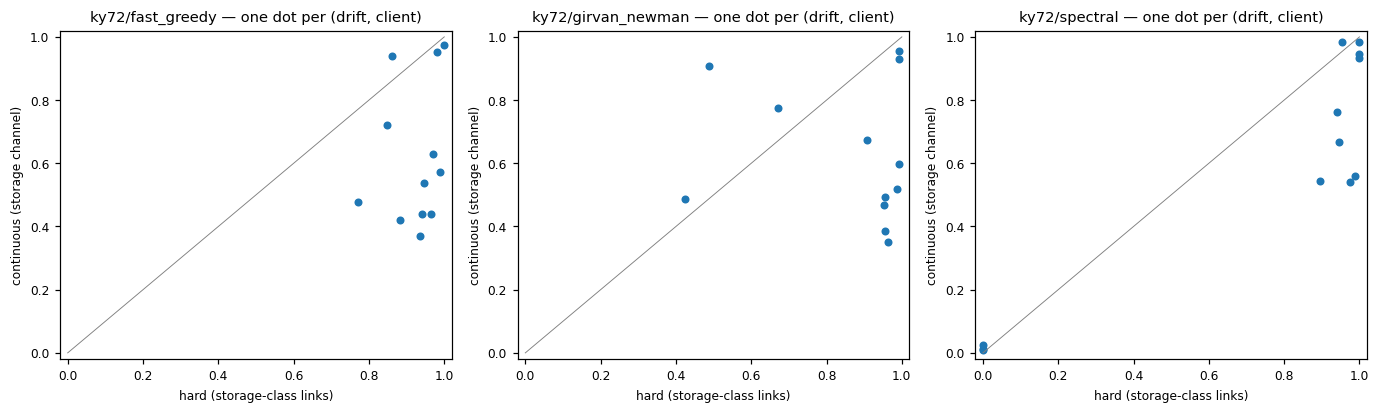

In [12]:
C1, rows = {}, []
for net, meth in PARTS:
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    names = sorted(g["drift"].unique())
    m_ = lambda col: (g.assign(v=g[col].abs()).groupby(["home", "drift"])["v"].mean()
                      .unstack("drift").reindex(index=names, columns=names))
    Dall = m_("gn")
    diag = np.diag(Dall.to_numpy(float))
    C1[(net, meth)] = {ch: m_(col).div(np.where(diag > 0, diag, np.nan), axis=0)
                       for ch, col in (("all", "gn"), ("demand", "gn_dem"), ("storage", "gn_sto"),
                                       ("residual", "gn_res"), ("null", "gn_null"))}
    sdn = T.get("stack_D_native")
    if sdn is not None:
        sdn = sdn[(sdn["network"] == net) & (sdn["districting"] == meth)]
        stack = sdn.pivot_table(index="j", columns="k", values="D").reindex(index=names, columns=names)
        C1[(net, meth)]["stack_native"] = rel(stack)
        for ch in ("all", "demand", "storage"):
            a, b = offdiag(C1[(net, meth)]["stack_native"]), offdiag(C1[(net, meth)][ch])
            ok = np.isfinite(a) & np.isfinite(b)
            rows.append({"network": net, "districting": meth, "channel": ch,
                         "offdiag_mean_R": float(np.nanmean(b)),
                         "stack_native_offdiag_mean_R": float(np.nanmean(a)),
                         "spearman_vs_stack_native": pd.Series(a[ok]).rank().corr(pd.Series(b[ok]).rank())
                         if ok.sum() > 3 else np.nan, "entries": int(ok.sum())})
pd.concat([Mx.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="R")
           .assign(network=key[0], districting=key[1], channel=ch)
           for key, v in C1.items() for ch, Mx in v.items()],
          ignore_index=True).to_parquet(OUT_DIR / "C1_long.parquet", index=False)
display(Markdown("**C1 — off-diagonal level per channel (relative to diag of the total) and ranking "
                 "agreement with the stack's native dependence**"))
display(pd.DataFrame(rows).round(3))

rows = []
for (net, meth, dr, hm), q in LK[LK["home"] != LK["drift"]].groupby(
        ["network", "districting", "drift", "home"]):
    tot = q["gabs"].sum()
    cd, cs = q["gn_dem"].abs().sum(), q["gn_sto"].abs().sum()
    rows.append({"network": net, "districting": meth, "drift": dr, "client": hm,
                 "hard_storage_share": q.loc[q["storage"], "gabs"].sum() / tot if tot > 0 else np.nan,
                 "continuous_storage_share": cs / (cd + cs) if cd + cs > 0 else np.nan})
C2 = pd.DataFrame(rows)
C2.to_parquet(OUT_DIR / "C2.parquet", index=False)
display(Markdown("**C2 — storage share of each client's off-diagonal response: hard vs continuous**"))
display(C2.set_index(["network", "districting", "drift", "client"]).round(2))
fig, axes = plt.subplots(1, len(PARTS), figsize=(4.2 * len(PARTS), 3.8), squeeze=False)
for ax, (net, meth) in zip(axes[0], PARTS):
    q = C2[(C2["network"] == net) & (C2["districting"] == meth)]
    ax.scatter(q["hard_storage_share"], q["continuous_storage_share"], s=18)
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.6)
    ax.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02), xlabel="hard (storage-class links)",
           ylabel="continuous (storage channel)", title=f"{net}/{meth} — one dot per (drift, client)")
fig.tight_layout(); plt.show()

## X — the KY7 attribution anomaly: hub-explained vs residual

Each storage link's standardised level change (S2) is split into the part its best hub element explains —
its init-window regression slope on that element times the element's own settled − init change, in the
same units — and the residual. Cosines between worlds of a partition, over links storage-class in both:

| reading | |
|---|---|
| `hub` ≈ ±1 and `residual` not | storage links move together through the hub; what distinguishes drifts is not the hub |
| `hub` itself not ±1 | the hub elements respond differently to different drifts (multi-hub, or regime changes) |

In [13]:
rows = []
for (net, meth), g in LK.groupby(["network", "districting"]):
    worlds = sorted(g["world"].unique())
    for a, b in combinations(worlds, 2):
        A = g[g["world"] == a].set_index("id")
        B = g[g["world"] == b].set_index("id")
        ids = [i for i in A.index.intersection(B.index) if A.at[i, "storage"] and B.at[i, "storage"]]
        row = {"network": net, "districting": meth, "drift_a": A["drift"].iat[0],
               "drift_b": B["drift"].iat[0], "links": len(ids)}
        for part, col in (("total", "S2_level"), ("hub", "S2_hub"), ("residual", "S2_res")):
            va, vb = A.loc[ids, col].to_numpy(float), B.loc[ids, col].to_numpy(float)
            ok = np.isfinite(va) & np.isfinite(vb)
            den = np.linalg.norm(va[ok]) * np.linalg.norm(vb[ok])
            row[part] = float(va[ok] @ vb[ok] / den) if den > 0 else np.nan
        rows.append(row)
XA = pd.DataFrame(rows)
XA.to_parquet(OUT_DIR / "X_attribution.parquet", index=False)
display(XA.round(2))
display(Markdown("**Share of the level change the hub explains** (median per world over storage links: "
                 "|S2_hub| / (|S2_hub| + |S2_res|))"))
sl = LK[LK["storage"]].assign(hub_share=lambda x: x["S2_hub"].abs() /
                              (x["S2_hub"].abs() + x["S2_res"].abs()))
display(sl.groupby(WKEY)["hub_share"].median().round(3).to_frame())

,network,districting,drift_a,drift_b,links,total,hub,residual
0,ky72,fast_greedy,District_A,District_B,323,0.34,0.96,0.43
1,ky72,fast_greedy,District_A,District_C,329,-0.78,-0.75,0.77
2,ky72,fast_greedy,District_A,District_D,327,-0.46,-0.78,-0.28
3,ky72,fast_greedy,District_B,District_C,324,-0.36,-0.78,0.52
4,ky72,fast_greedy,District_B,District_D,321,-0.13,-0.83,0.06
5,ky72,fast_greedy,District_C,District_D,328,0.34,0.85,-0.28
6,ky72,girvan_newman,District_C,District_A,311,-0.09,-0.72,0.57
7,ky72,girvan_newman,District_C,District_B,304,-0.20,-0.83,0.21
8,ky72,girvan_newman,District_C,District_D,320,0.06,0.77,-0.06
9,ky72,girvan_newman,District_A,District_B,299,0.45,0.83,-0.14


**Share of the level change the hub explains** (median per world over storage links: |S2_hub| / (|S2_hub| + |S2_res|))

hub_share
network districting   drift      world              
ky72    fast_greedy   District_A 0b4750d3      0.658
                      District_B 13f0f426      0.493
                      District_C 312ef90c      0.835
                      District_D 8a9b36d7      0.549
        girvan_newman District_A 35d8d9bc      0.100
                      District_B 420262ff      0.533
                      District_C 13e16814      0.503
                      District_D f90a7f06      0.835
        spectral      District_A 27ccb25e      0.596
                      District_B dabef050      0.554
                      District_C 44043280      0.559
                      District_D d767277b      0.940

## V — visualisations

1. **Network maps** per partition: links coloured by set (majority over worlds); a second map by class
   stability; a third by the hub element storage links observe. Tanks ■, reservoirs ◆, pumps ▲.
2. **S1 timelines** per world: links (rows, sorted by set then home) × months, colour = S1 ratio (log);
   vertical lines at the first switch and the settled window.
3. **Example series** per set (init vs settled, 14 days), with the home district's demand.
4. **Matrices**: stack $R$, empirical $R$ (all / demand / dedup), noise floor, observational (raw / anom,
   demand vs storage).

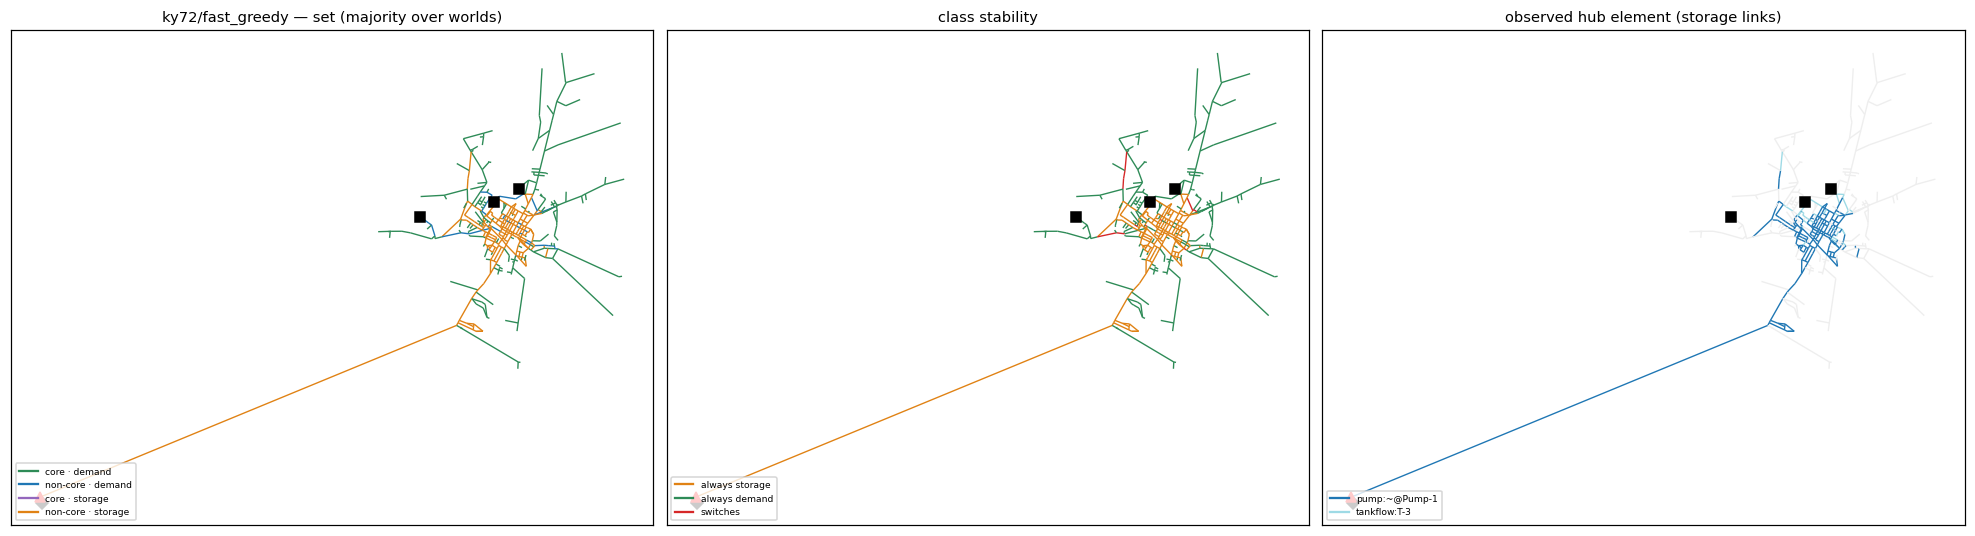

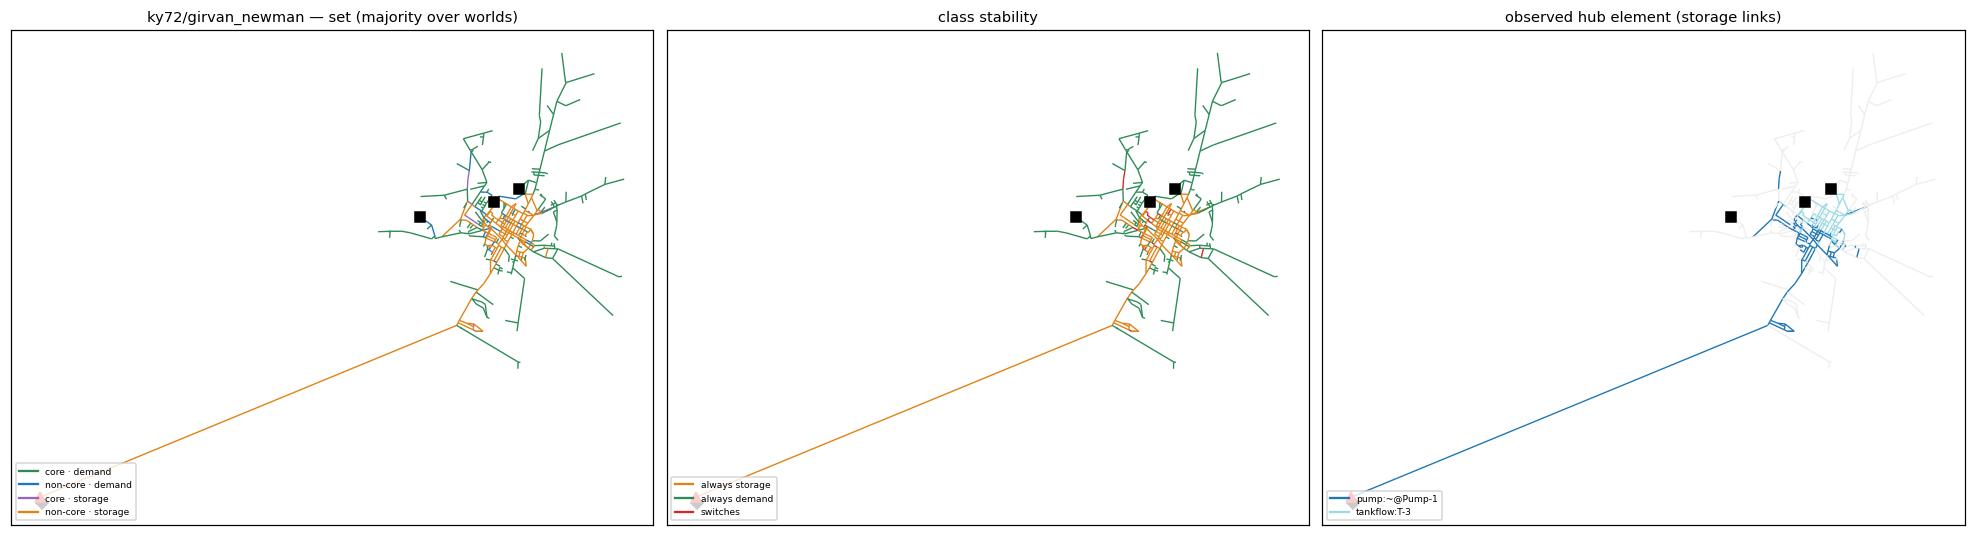

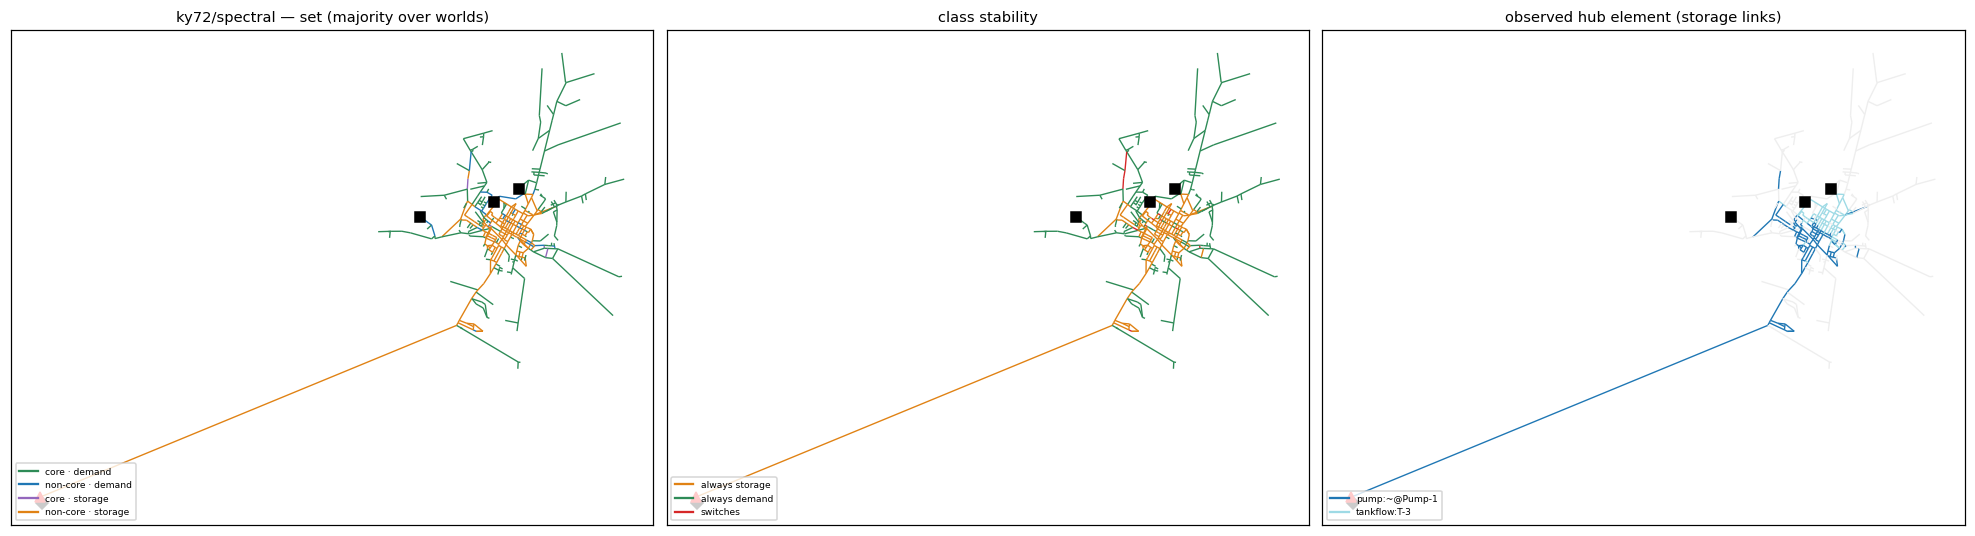

In [14]:
def draw_network(ax, wn, colour_of, title, legend=None):
    segs, cols = [], []
    for ln in wn.link_name_list:
        l = wn.get_link(ln)
        a, b = wn.get_node(l.start_node_name).coordinates, wn.get_node(l.end_node_name).coordinates
        segs.append([a, b]); cols.append(colour_of(ln))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.9))
    for t in wn.tank_name_list:
        x, y = wn.get_node(t).coordinates; ax.plot(x, y, "s", ms=6, color="k")
    for rv in wn.reservoir_name_list:
        x, y = wn.get_node(rv).coordinates; ax.plot(x, y, "D", ms=6, color="k")
    for p in wn.pump_name_list:
        l = wn.get_link(p)
        a, b = wn.get_node(l.start_node_name).coordinates, wn.get_node(l.end_node_name).coordinates
        ax.plot((a[0] + b[0]) / 2, (a[1] + b[1]) / 2, "^", ms=6, color="r")
    ax.autoscale(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    if legend:
        ax.legend(handles=legend, fontsize=6, loc="lower left")


for net, meth in PARTS:
    wn = NETS[net]
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    maj = g.groupby("element").agg(set=("set", lambda s: s.mode().iat[0]),
                                   share=("storage", "mean"),
                                   hub=("S3_hub", lambda s: s.mode().iat[0] if s.notna().any() else None))
    maj.index = maj.index.astype(str)
    hubs = sorted(maj.loc[maj["share"] >= 0.5, "hub"].dropna().unique())
    hub_col = {h_: tuple(c_) for h_, c_ in zip(hubs, plt.cm.tab20(np.linspace(0, 1, max(len(hubs), 1))))}
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    draw_network(axes[0], wn, lambda ln: SET_COLOUR.get(maj["set"].get(ln), "#dddddd"),
                 f"{net}/{meth} — set (majority over worlds)",
                 [Line2D([], [], color=c, label=s) for s, c in SET_COLOUR.items()])
    stab = lambda ln: ("#dddddd" if ln not in maj.index else
                       "#e08214" if maj.at[ln, "share"] == 1 else
                       "#2e8b57" if maj.at[ln, "share"] == 0 else "#d62728")
    draw_network(axes[1], wn, stab, "class stability",
                 [Line2D([], [], color=c, label=s) for s, c in
                  (("always storage", "#e08214"), ("always demand", "#2e8b57"), ("switches", "#d62728"))])
    draw_network(axes[2], wn, lambda ln: hub_col.get(maj["hub"].get(ln), "#eeeeee")
                 if ln in maj.index and maj.at[ln, "share"] >= 0.5 else "#eeeeee",
                 "observed hub element (storage links)",
                 [Line2D([], [], color=c, label=h) for h, c in hub_col.items()])
    fig.tight_layout(); plt.show()

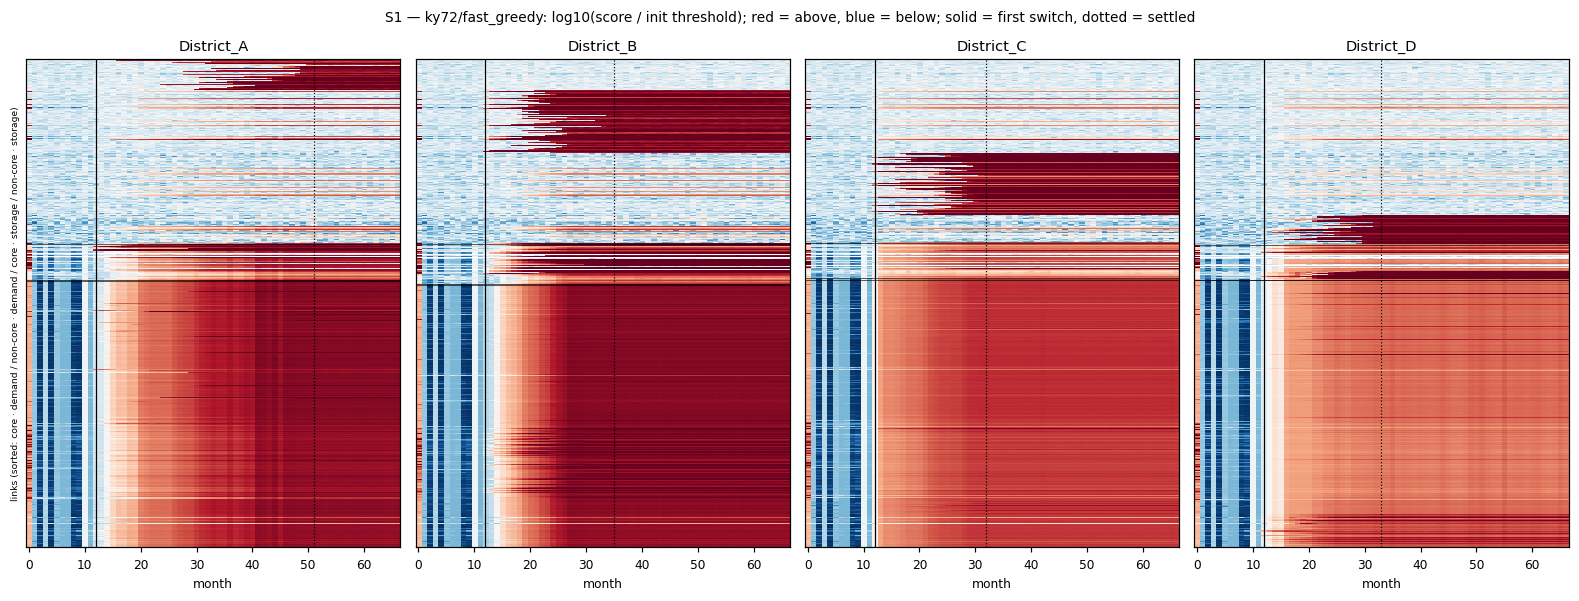

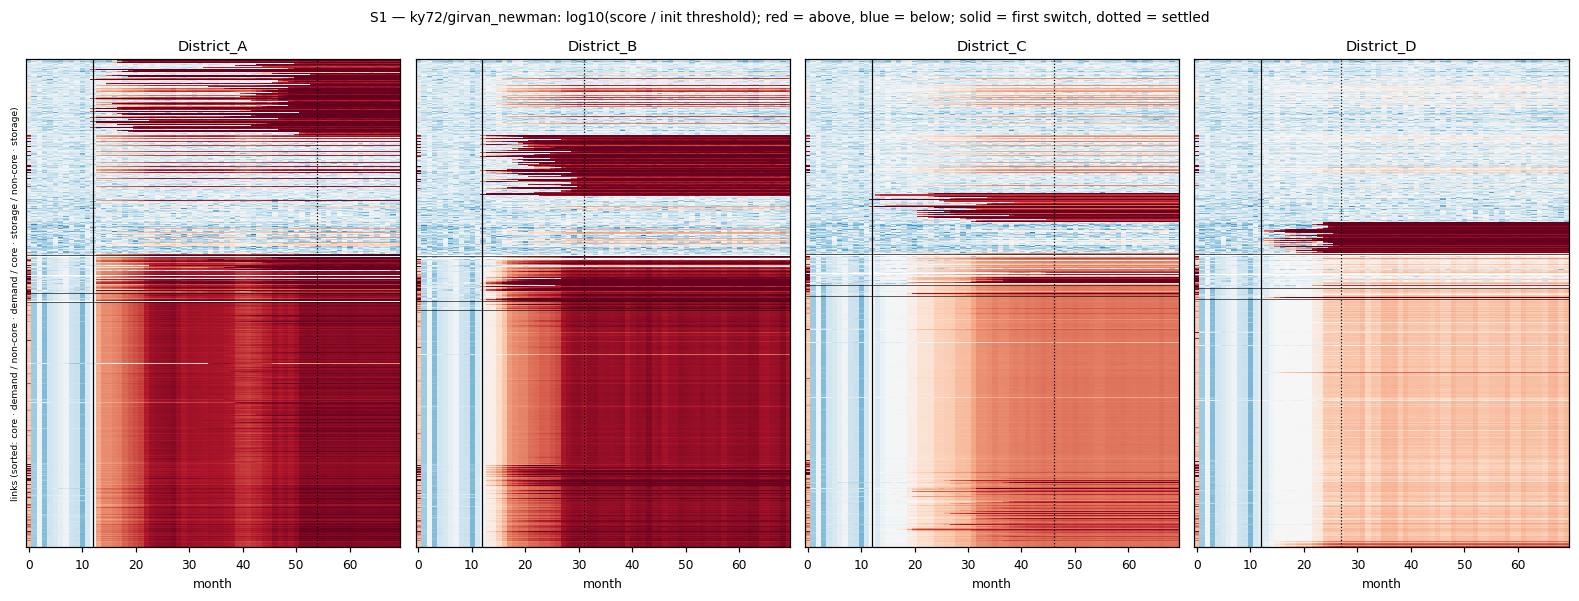

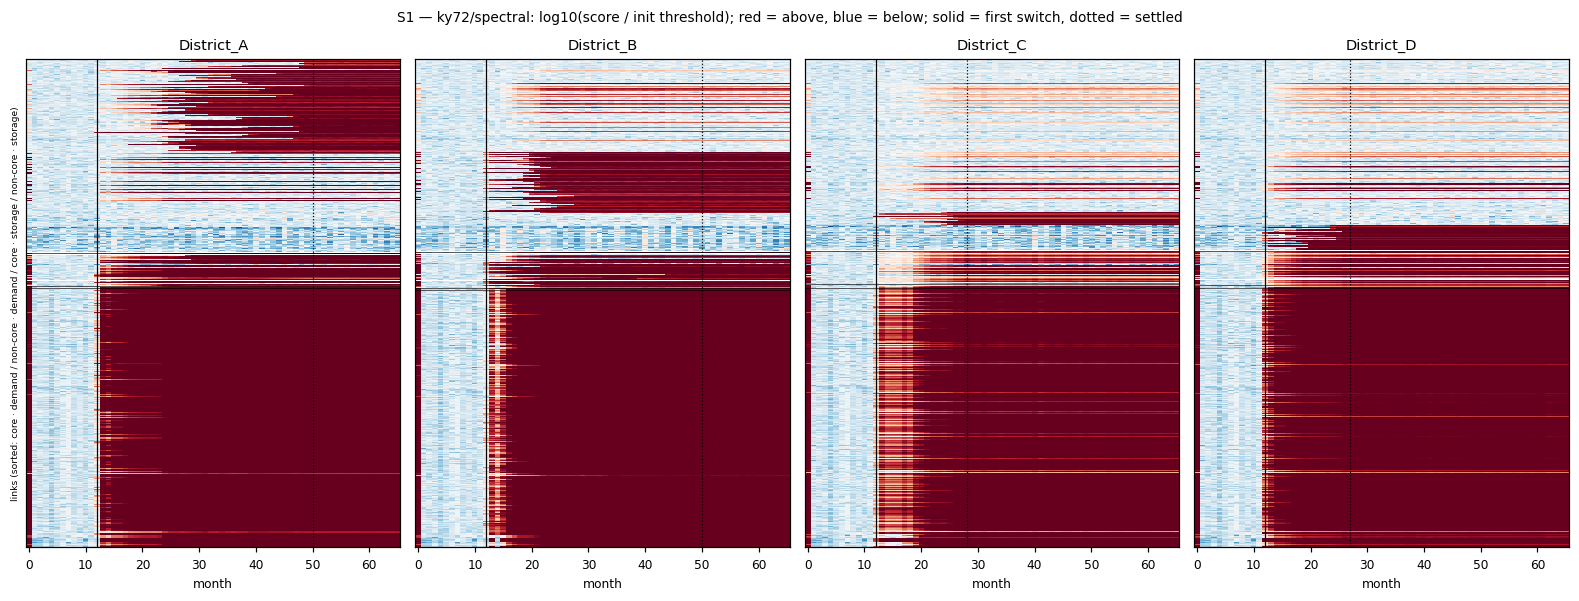

In [15]:
ML = T["monthly_links"].merge(LK[WKEY + ["id", "set", "home"]], on=WKEY + ["id"], how="left")
for net, meth in PARTS:
    worlds = LK[(LK["network"] == net) & (LK["districting"] == meth)][WKEY].drop_duplicates()
    fig, axes = plt.subplots(1, len(worlds), figsize=(3.6 * len(worlds), 5.5), squeeze=False)
    for ax, (_, wr) in zip(axes[0], worlds.iterrows()):
        q = ML[(ML["world"] == wr["world"])]
        order = (LK[LK["world"] == wr["world"]].assign(si=lambda x: x["set"].map(
                 {s: i for i, s in enumerate(SETS)}).fillna(9)).sort_values(["si", "home"])["id"])
        piv = q.pivot_table(index="id", columns="month", values="ratio").reindex(order)
        ax.imshow(np.log10(piv.clip(lower=1e-2).to_numpy()), aspect="auto", cmap="RdBu_r",
                  vmin=-1, vmax=1, interpolation="nearest")
        wrow = T["worlds"][T["worlds"]["world"] == wr["world"]].iloc[0]
        ax.axvline(wrow["first_month"], color="k", lw=0.8)
        ax.axvline(wrow["settled_month"], color="k", lw=0.8, ls=":")
        sizes = LK[LK["world"] == wr["world"]]["set"].value_counts().reindex(SETS).fillna(0).cumsum()
        for y in sizes.to_numpy()[:-1]:
            ax.axhline(y, color="k", lw=0.4)
        ax.set(title=f"{wr['drift']}", xlabel="month", yticks=[])
    axes[0][0].set_ylabel("links (sorted: " + " / ".join(SETS) + ")", fontsize=6)
    fig.suptitle(f"S1 — {net}/{meth}: log10(score / init threshold); red = above, blue = below; "
                 "solid = first switch, dotted = settled", fontsize=9)
    fig.tight_layout(); plt.show()

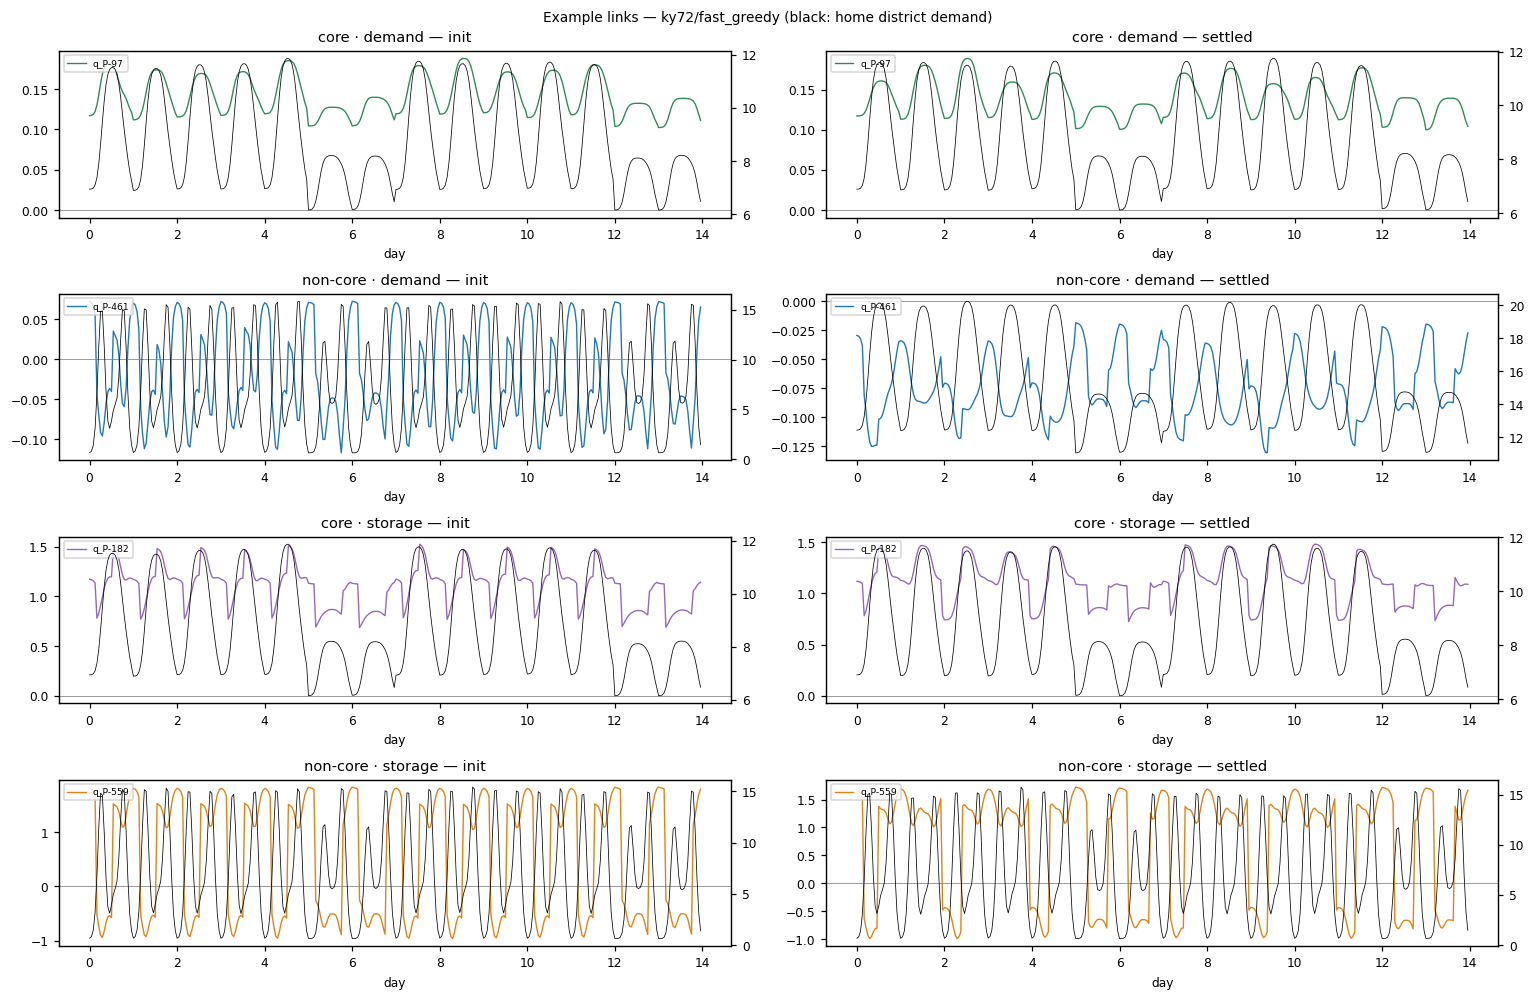

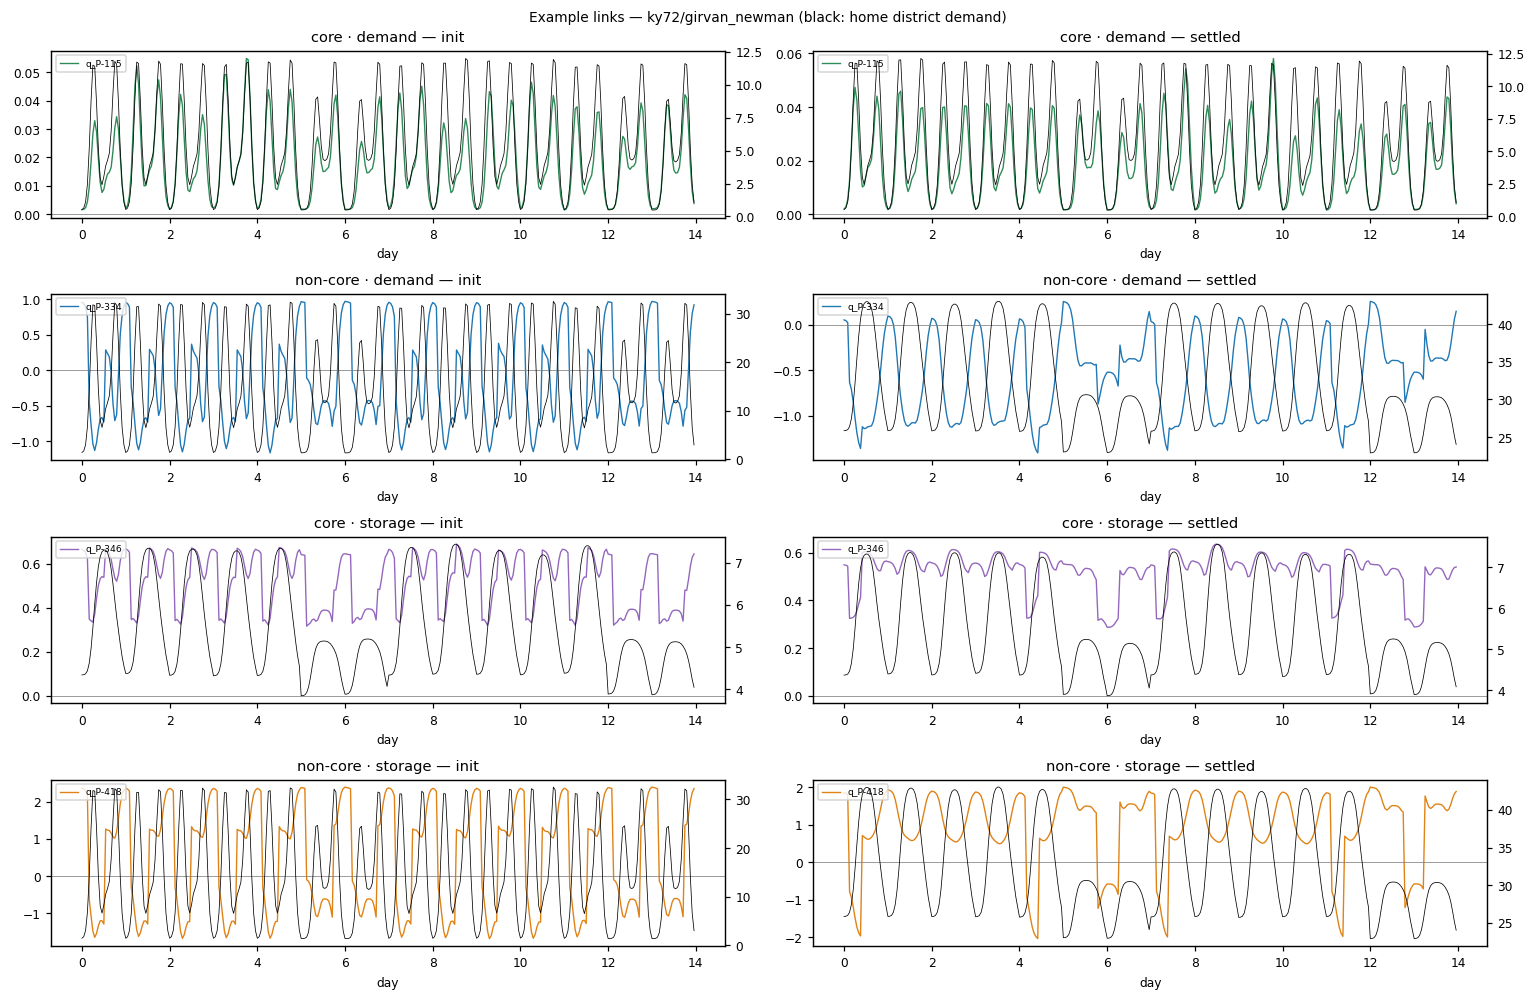

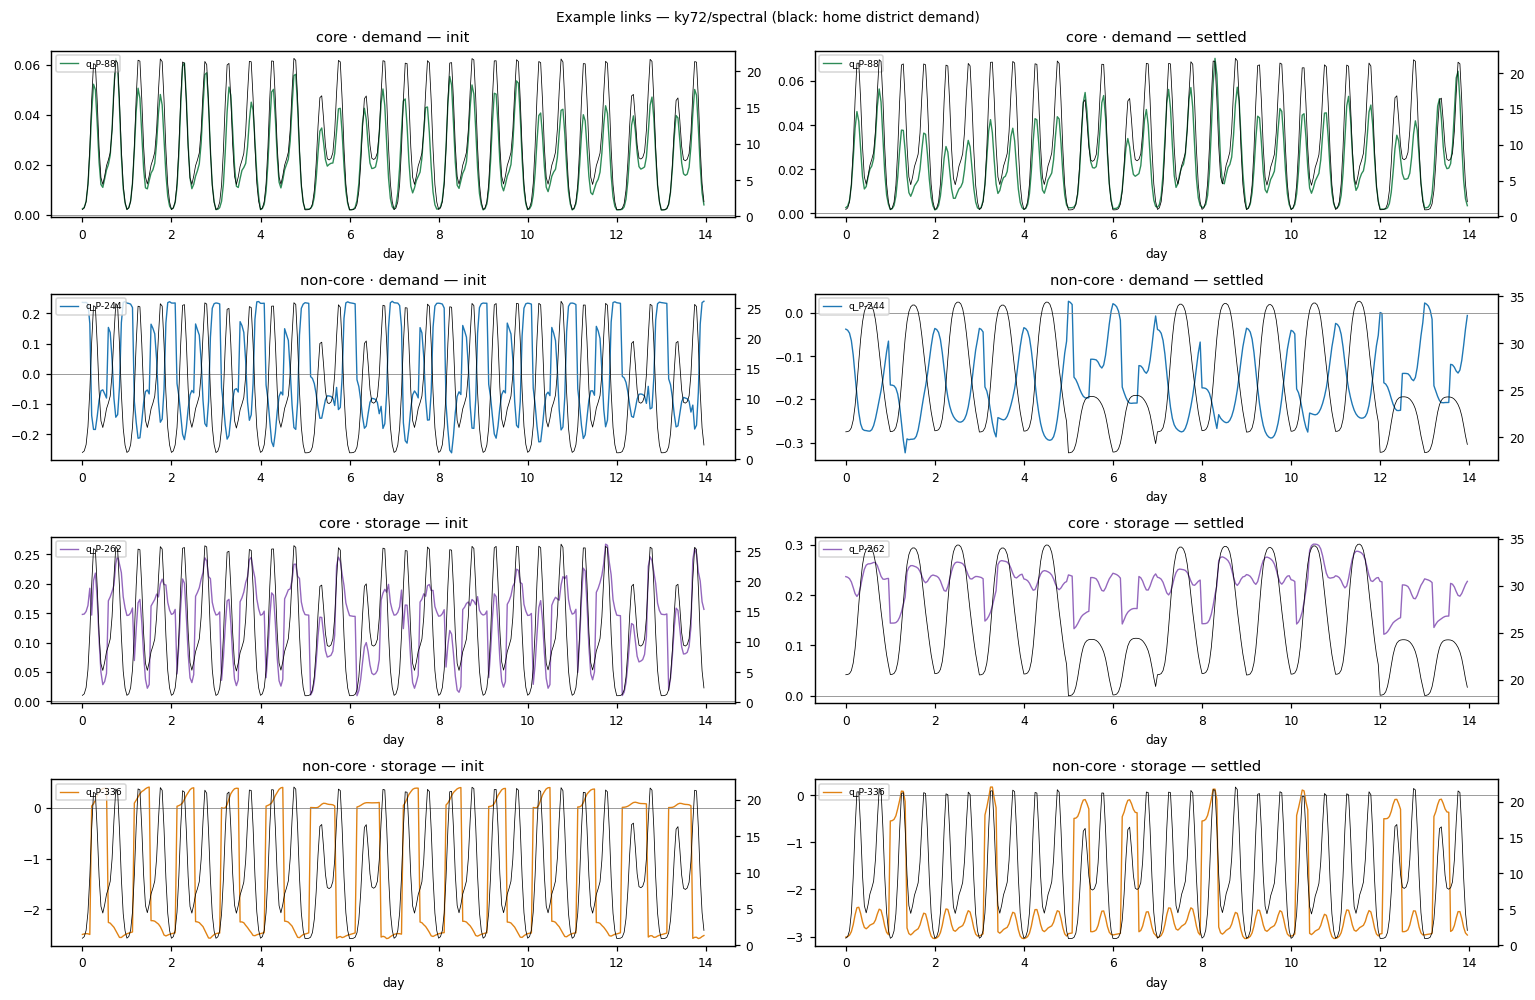

In [16]:
EX = T["examples"]
for (net, meth), g in EX.groupby(["network", "districting"]):
    sets = [s for s in SETS if s in g["set"].unique()]
    fig, axes = plt.subplots(len(sets), 2, figsize=(14, 2.3 * len(sets)), squeeze=False)
    for i, s in enumerate(sets):
        for j, wname in enumerate(("init", "settled")):
            q = g[(g["set"] == s) & (g["window"] == wname)]
            ax = axes[i][j]
            ax.plot(q["hour"] / 24, q["flow"], color=SET_COLOUR[s], lw=0.9, label=q["id"].iat[0])
            ax2 = ax.twinx(); ax2.plot(q["hour"] / 24, q["home_demand"], color="k", lw=0.5)
            ax.axhline(0, color="0.5", lw=0.5)
            ax.set(title=f"{s} — {wname}", xlabel="day"); ax.legend(fontsize=6, loc="upper left")
    fig.suptitle(f"Example links — {net}/{meth} (black: home district demand)", fontsize=9)
    fig.tight_layout(); plt.show()

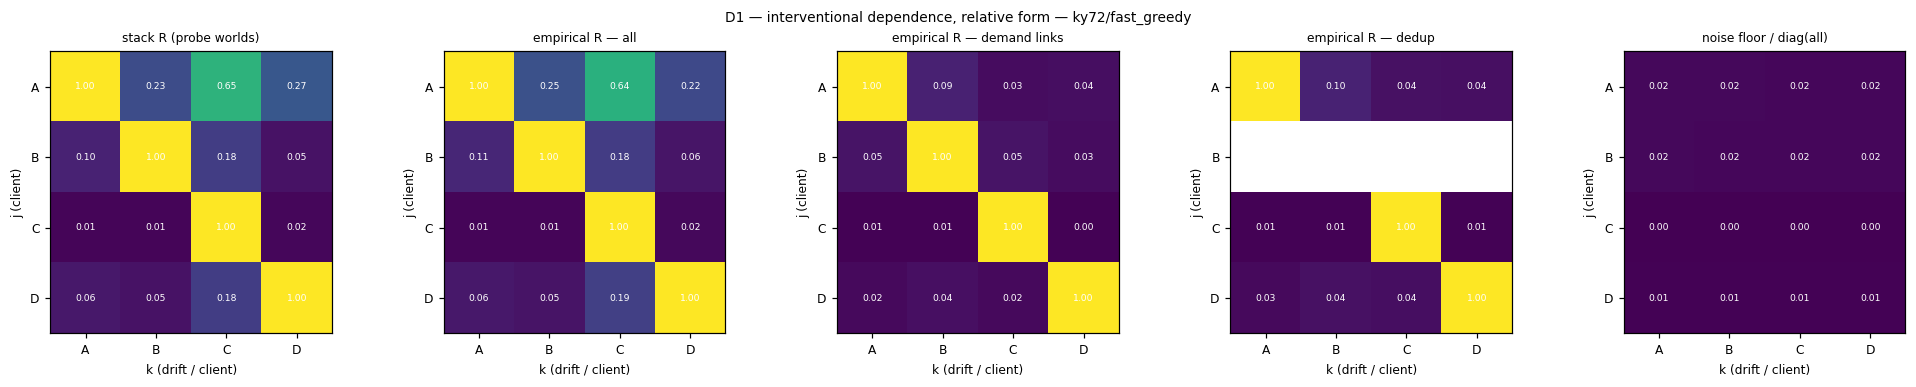

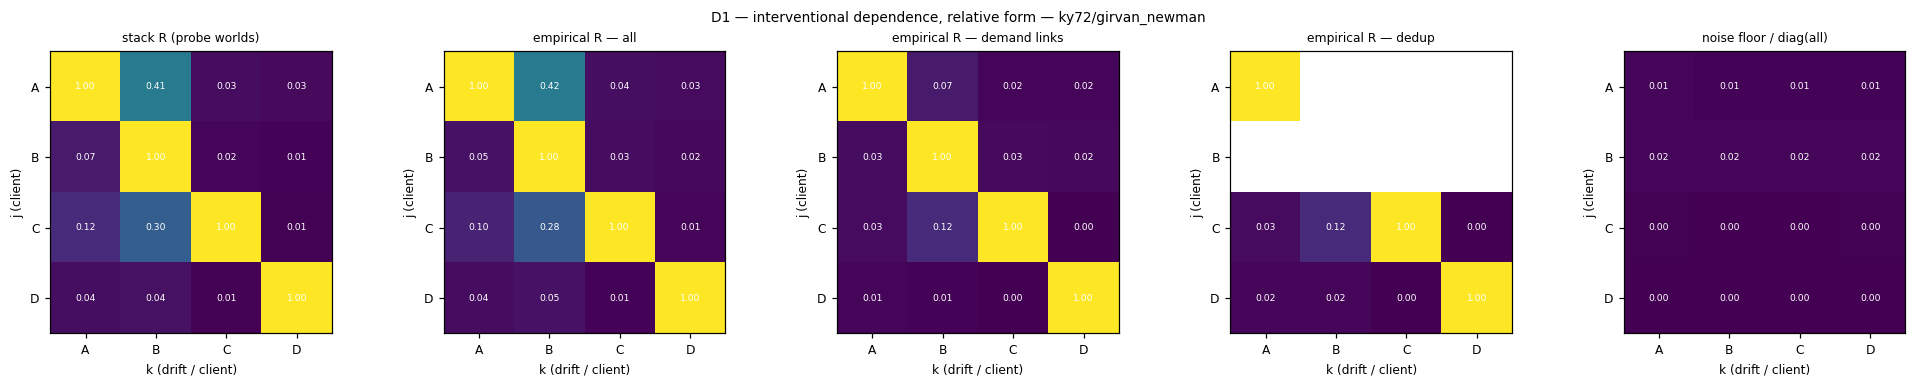

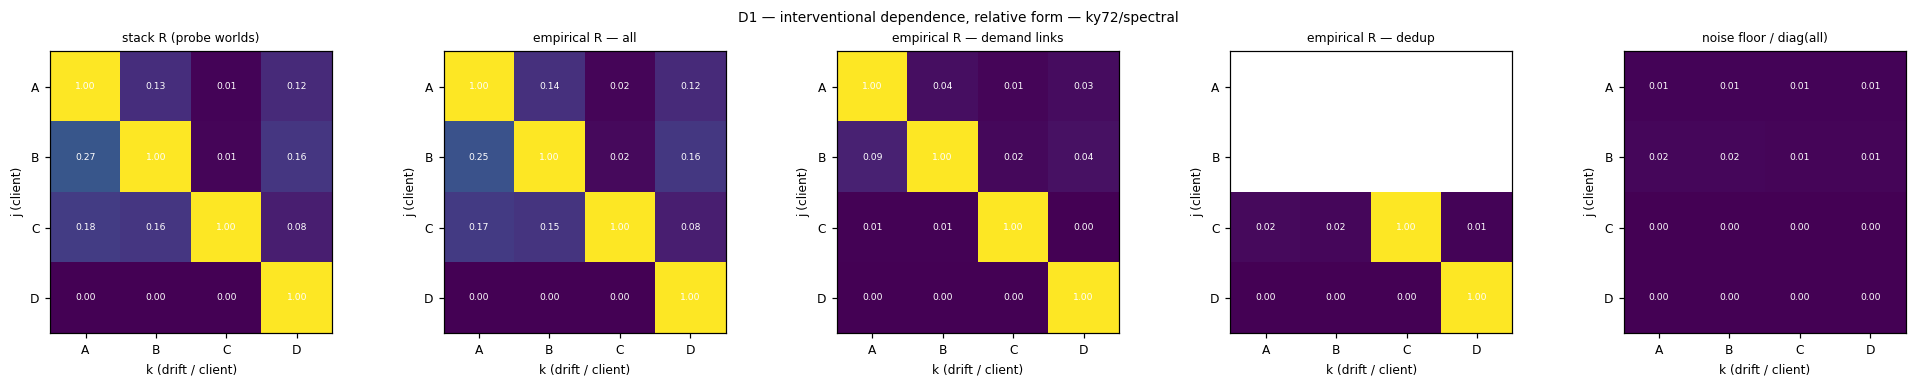

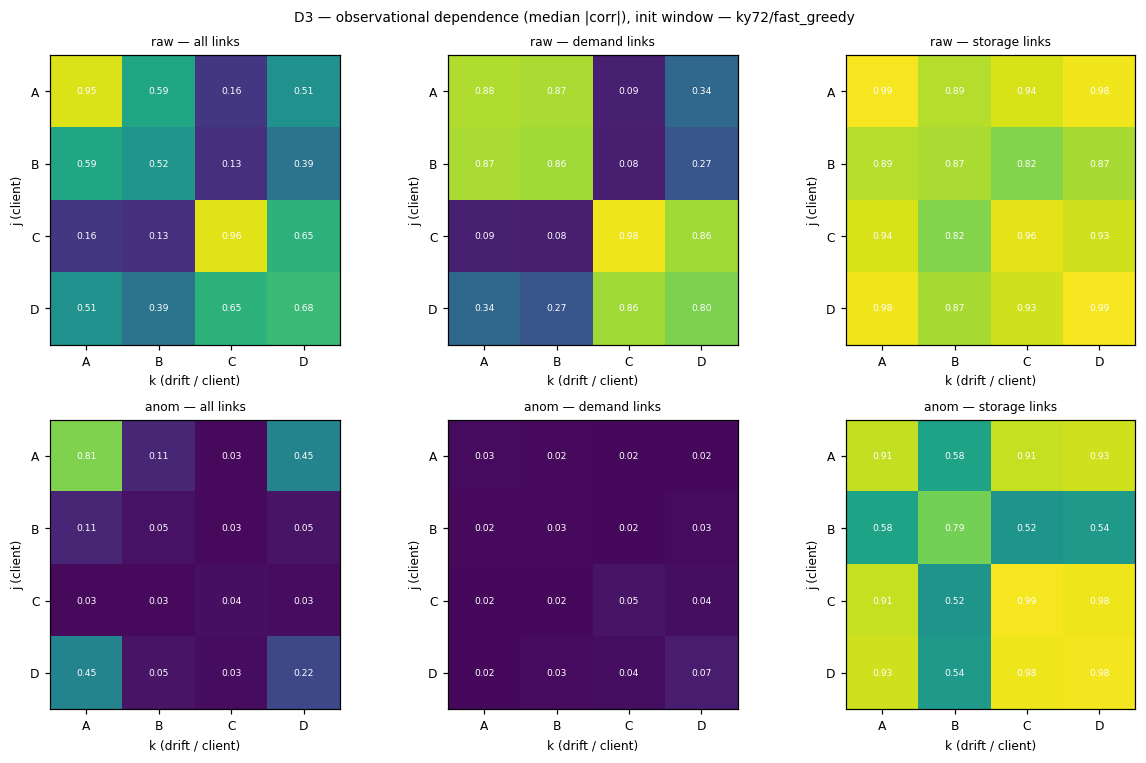

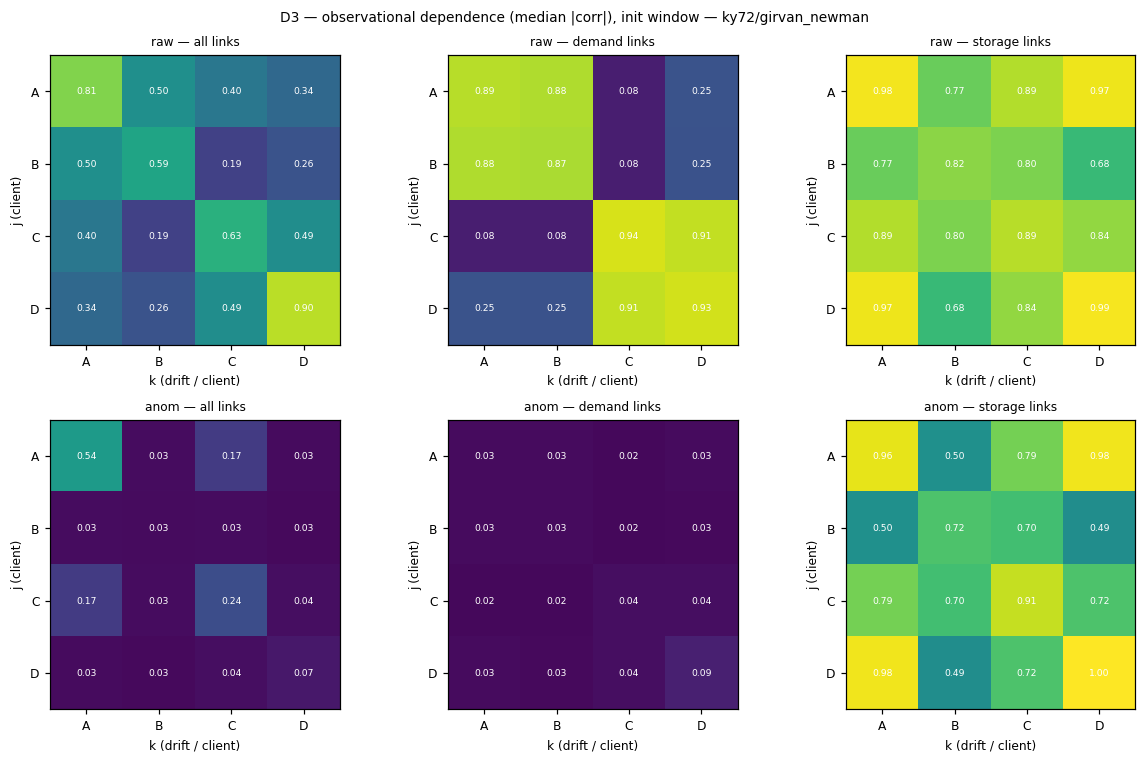

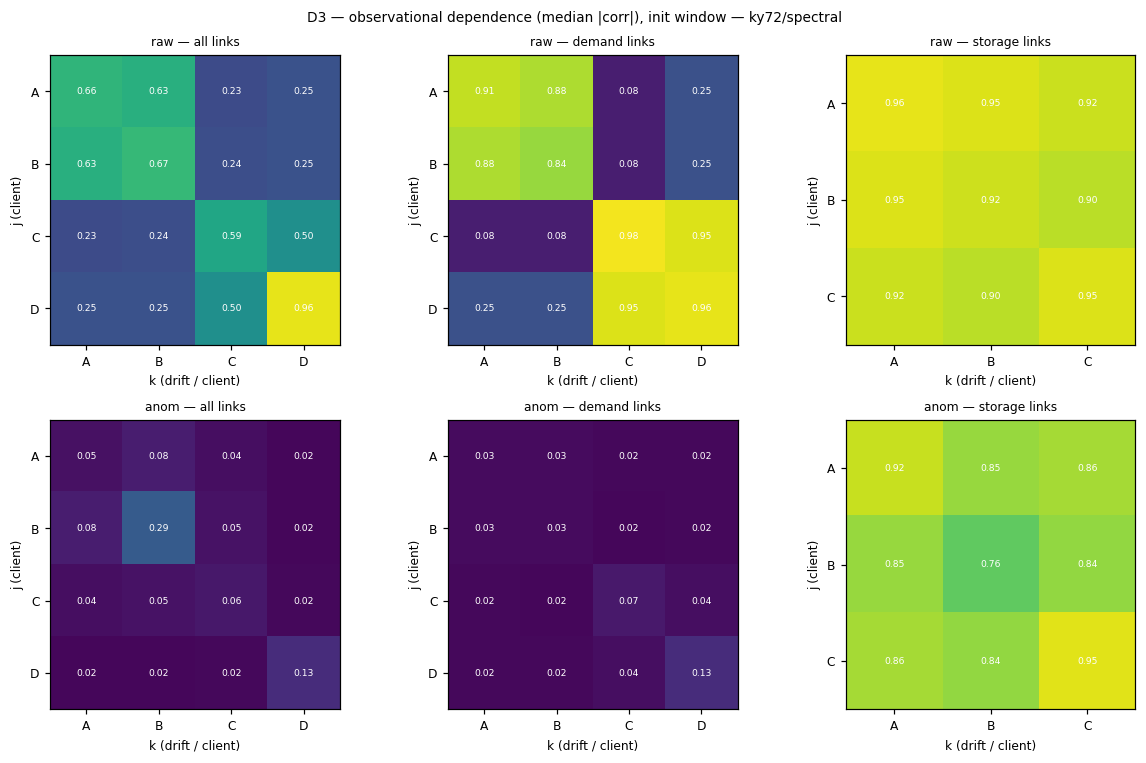

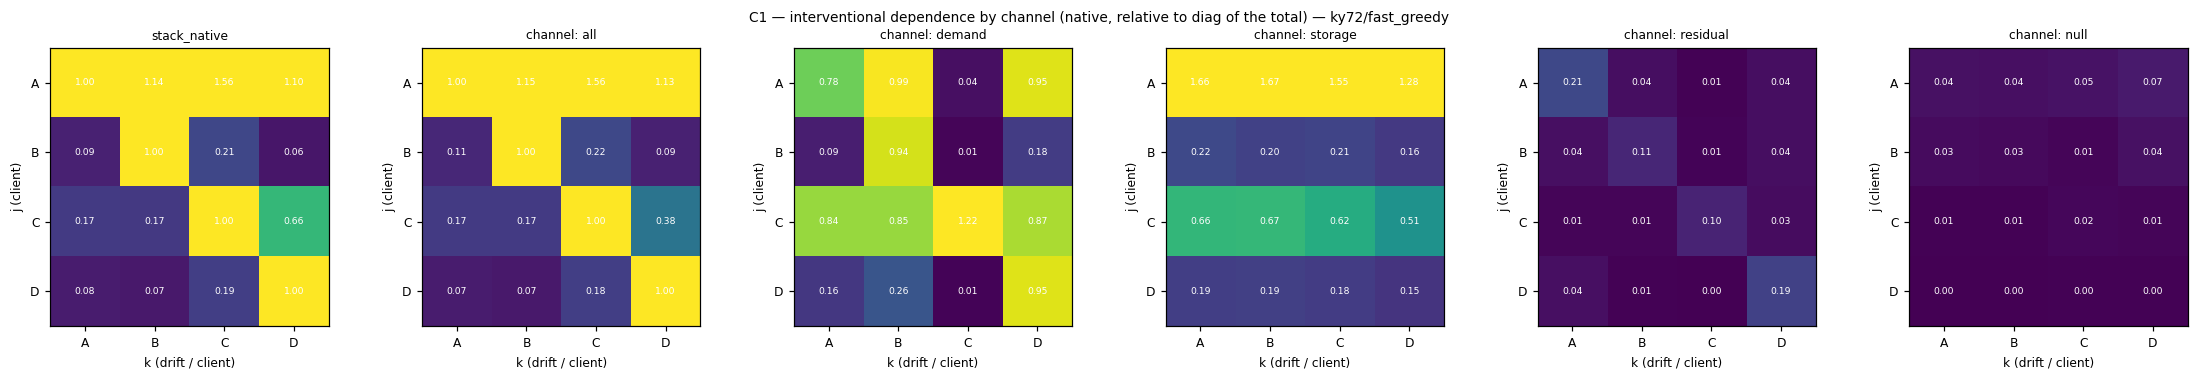

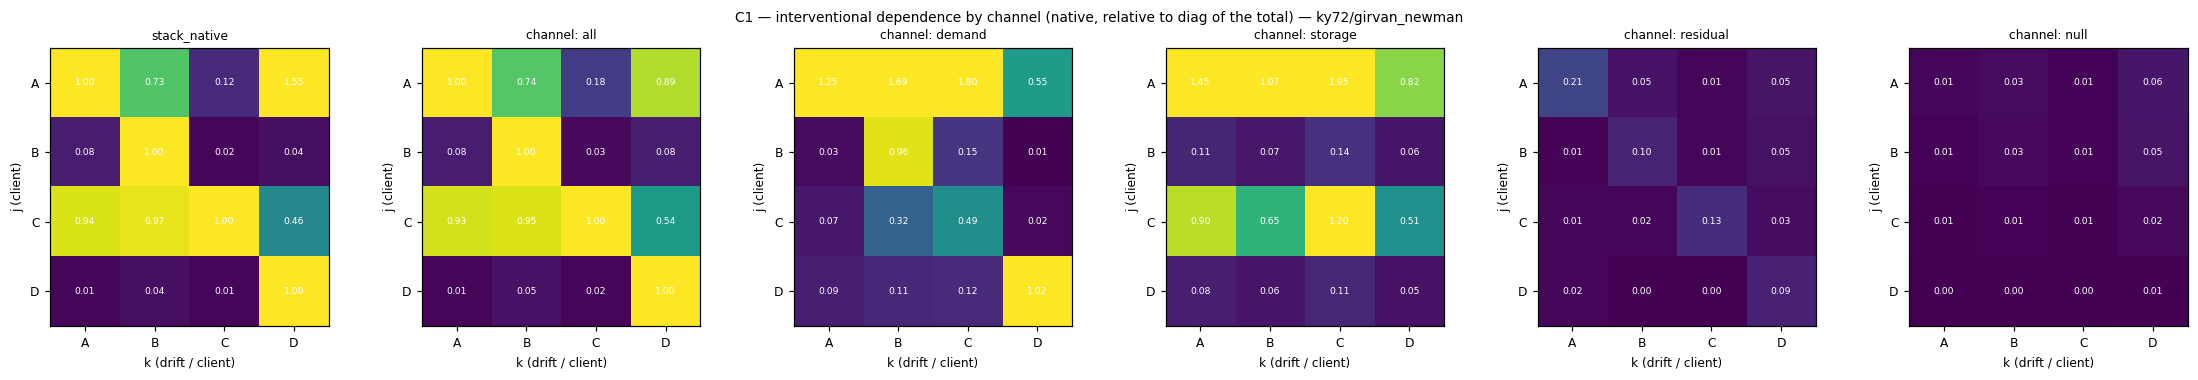

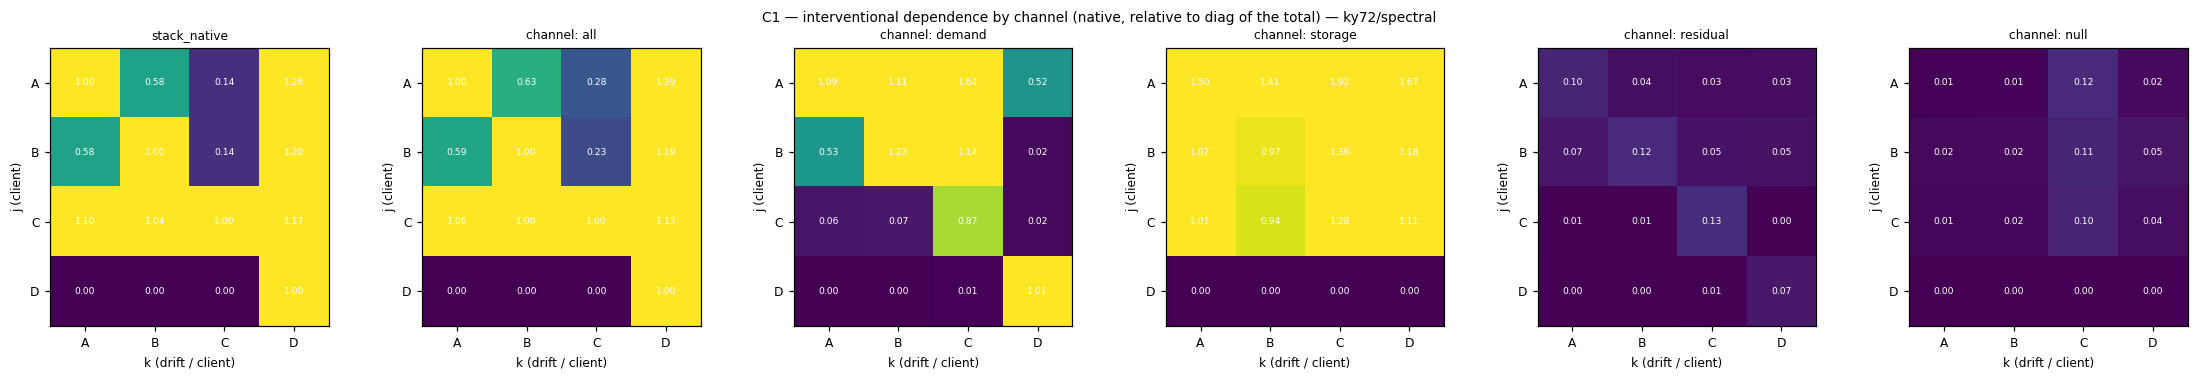

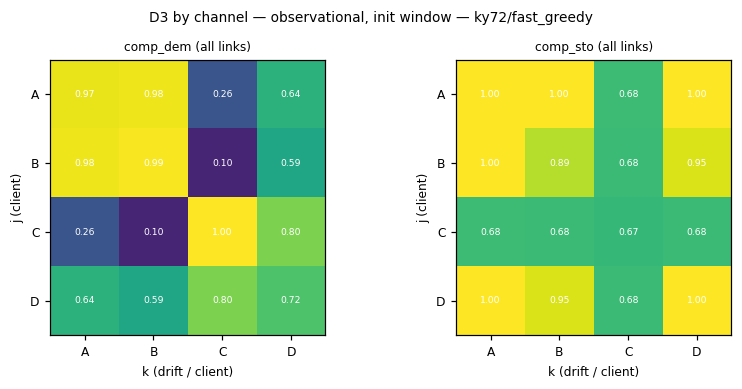

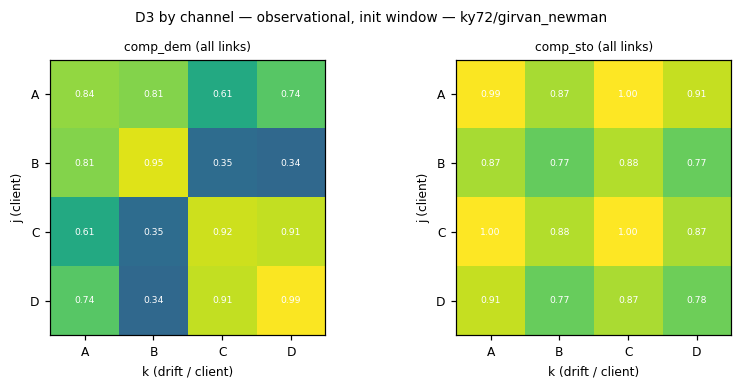

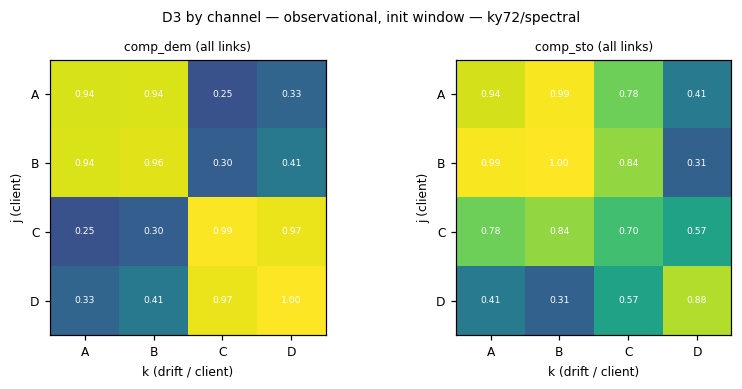

In [17]:
def heat(ax, Mx, title, vmax=None):
    A = Mx.to_numpy(float)
    im = ax.imshow(A, cmap="viridis", vmin=0, vmax=vmax if vmax else np.nanmax(A))
    ax.set_xticks(range(A.shape[1])); ax.set_xticklabels([c[-1] for c in Mx.columns])
    ax.set_yticks(range(A.shape[0])); ax.set_yticklabels([str(c)[-1] if str(c) != "hub" else "hub"
                                                           for c in Mx.index])
    for (y, x), v in np.ndenumerate(A):
        if np.isfinite(v):
            ax.text(x, y, f"{v:.2f}", ha="center", va="center", fontsize=6, color="w")
    ax.set_title(title, fontsize=8); ax.set_xlabel("k (drift / client)"); ax.set_ylabel("j (client)")


for key, v in D1.items():
    sd_ = T["stack_D"]
    sd_ = sd_[(sd_["network"] == key[0]) & (sd_["districting"] == key[1])]
    stack = sd_.pivot_table(index="j", columns="k", values="D").reindex(
        index=v["all"].index, columns=v["all"].columns)
    panels = [("stack R (probe worlds)", rel(stack)), ("empirical R — all", rel(v["all"])),
              ("empirical R — demand links", rel(v["demand"])), ("empirical R — dedup", rel(v["dedup"])),
              ("noise floor / diag(all)",
               v["null"].div(np.diag(v["all"].to_numpy(float)), axis=0))]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 3.4))
    for ax, (t, Mx) in zip(axes, panels):
        heat(ax, Mx, t, vmax=1.0)
    fig.suptitle(f"D1 — interventional dependence, relative form — {key[0]}/{key[1]}", fontsize=9)
    fig.tight_layout(); plt.show()

for (net, meth), g in OBS.groupby(["network", "districting"]):
    fig, axes = plt.subplots(2, 3, figsize=(11, 7))
    for i, sig in enumerate(("raw", "anom")):
        for j, sub in enumerate(("all", "demand", "storage")):
            q = g[(g["signal"] == sig) & (g["subset"] == sub)]
            heat(axes[i][j], q.pivot_table(index="j", columns="k", values="O"),
                 f"{sig} — {sub} links", vmax=1.0)
    fig.suptitle(f"D3 — observational dependence (median |corr|), init window — {net}/{meth}", fontsize=9)
    fig.tight_layout(); plt.show()

for key, v in C1.items():
    panels = [(ch, v[ch]) for ch in ("stack_native", "all", "demand", "storage", "residual", "null") if ch in v]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.3))
    for ax, (t, Mx) in zip(np.atleast_1d(axes), panels):
        heat(ax, Mx, t if t == "stack_native" else f"channel: {t}", vmax=1.0)
    fig.suptitle(f"C1 — interventional dependence by channel (native, relative to diag of the total) "
                 f"— {key[0]}/{key[1]}", fontsize=9)
    fig.tight_layout(); plt.show()

for (net, meth), g in OBS[OBS["signal"].isin(["comp_dem", "comp_sto"])].groupby(["network", "districting"]):
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))
    for ax, sig in zip(axes, ("comp_dem", "comp_sto")):
        q = g[g["signal"] == sig]
        heat(ax, q.pivot_table(index="j", columns="k", values="O"), f"{sig} (all links)", vmax=1.0)
    fig.suptitle(f"D3 by channel — observational, init window — {net}/{meth}", fontsize=9)
    fig.tight_layout(); plt.show()